# Part 1: LOW_FINALE


In [ ]:
# ── Mount Google Drive ────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
####### Module 1 : Import libraries #######
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
plt.rcParams['figure.dpi']     = 120
plt.rcParams['figure.figsize'] = (15, 12)
import seaborn as sns
from datetime import datetime
import warnings, gc, os, zipfile, glob
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler, RobustScaler
print('All libraries imported successfully!')


In [ ]:
####### Module 2: Import SHAP #######
import shap
print("SHAP imported successfully!")

from IPython.display import display as ipy_display
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass

SHAP imported successfully!


In [ ]:
####### Module 3 : Constants #######
LAMBDA      = 2.45e6
R           = 8.314
LP          = 1.0
LATITUDE    = 0.205258
RAIN_THRESH = 500.0

FLUXNET_COL_MAP = {
    'TIMESTAMP_START' : 'DateTime',
    'TA_F'            : 'Ta',
    'SW_IN_F'         : 'SWin',
    'SW_OUT'          : 'SWout',
    'LW_IN_F'         : 'LWin',
    'LW_OUT'          : 'LWout',
    'VPD_F'           : 'VPD_F',
    'PA_F'            : 'PA',
    'WS_F'            : 'WS',
    'RH'              : 'RH',
    'NETRAD'          : 'NETRAD',
    'G_F_MDS'         : 'G',
    'USTAR'           : 'USTAR',
    'CO2_F_MDS'       : 'CO2',
    'SWC_F_MDS_1'     : 'SWC1',
    'SWC_F_MDS_2'     : 'SWC2',
    'P_F'             : 'P',
    'LE_F_MDS'        : 'LE',
    'NEE_VUT_REF'     : 'NEE',
    'GPP_NT_VUT_REF'  : 'GPP',
}

# Base features derived from daily aggregation
BASE_FEATURES = [
    'VPDmin_day', 'NET_SW_mean', 'NET_LW_mean',
    'DTR_mean',   'SW_ratio_mean', 'SM_mean',
    'WS_mean',    'Ta_mean_day'
]

# Full feature set including engineered interactions and rolling terms
LOW_RAIN_FEATURES = [
    'VPDmin_day', 'NET_SW_mean', 'NET_LW_mean',
    'DTR_mean',   'SW_ratio_mean', 'SM_mean',
    'WS_mean',    'Ta_mean_day',
    'Rn_x_SM', 'VPD_x_SM', 'Rn_x_VPD', 'Ta_x_VPD',
    'SM_roll3', 'NET_SW_roll3', 'VPD_roll3',
]

TARGET_COL  = 'ET_day'
GROUP_LABEL = 'Low Rainfall'
BAR_COLOR   = '#ff7f0e'

print('Constants defined for LOW RAINFALL')
print(f'Total features: {len(LOW_RAIN_FEATURES)}')


In [ ]:
####### Module 4: Radiation calculation functions #######
def day_of_year(tindex):
    return tindex.dayofyear

def relative_distance(j):
    return 1 + 0.033 * np.cos(2 * np.pi * j / 365)

def solar_declination(j):
    return 0.409 * np.sin(2 * np.pi * j / 365 - 1.39)

def sunset_angle(sol_dec, lat):
    return np.arccos(-np.tan(lat) * np.tan(sol_dec))

def extraterrestrial_radiation(tindex, lat):
    j       = day_of_year(tindex)
    dr      = relative_distance(j)
    sol_dec = solar_declination(j)
    omega   = sunset_angle(sol_dec, lat)
    ra = (118.08 / np.pi) * dr * (
        omega * np.sin(sol_dec) * np.sin(lat) +
        np.cos(sol_dec) * np.cos(lat) * np.sin(omega)
    )
    return ra

print("Radiation functions defined.")

Radiation functions defined.


In [ ]:
####### Module 5: Data loading function #######
def load_fluxnet_csv(file_path):
    try:
        needed_fluxnet_cols = list(FLUXNET_COL_MAP.keys())
        all_cols = pd.read_csv(file_path, nrows=0).columns.tolist()
        use_cols = [c for c in needed_fluxnet_cols if c in all_cols]

        df = pd.read_csv(
            file_path,
            usecols=use_cols,
            dtype=np.float32,
            na_values=[-9999, -9999.0]
        )

        rename_map = {k: v for k, v in FLUXNET_COL_MAP.items() if k in df.columns}
        df.rename(columns=rename_map, inplace=True)

        if 'DateTime' in df.columns:
            df['DateTime'] = pd.to_datetime(
                df['DateTime'].astype(np.int64).astype(str),
                format='%Y%m%d%H%M', errors='coerce'
            )
        else:
            print(f"  WARNING: No TIMESTAMP_START in {file_path}")
            return pd.DataFrame()

        gc.collect()
        return df

    except Exception as e:
        print(f"  Error loading {file_path}: {e}")
        return pd.DataFrame()


def load_zip_sites(zip_path, label):
    print(f"\nLoading {label} rainfall sites from: {zip_path}")
    site_dfs = {}

    extract_dir = f'tmp_{label.replace(" ", "_")}'
    os.makedirs(extract_dir, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'r') as z:
        csv_files = [f for f in z.namelist() if f.endswith('.csv')]
        print(f"  Found {len(csv_files)} CSV files")
        z.extractall(extract_dir)

    all_csv = glob.glob(os.path.join(extract_dir, '**', '*.csv'), recursive=True)
    for csv_file in all_csv:
        basename = os.path.basename(csv_file)
        parts    = basename.split('_')
        site_id  = parts[1] if len(parts) > 1 else basename.replace('.csv', '')

        df = load_fluxnet_csv(csv_file)
        if df.empty:
            continue

        if site_id in site_dfs:
            site_dfs[site_id] = pd.concat([site_dfs[site_id], df], ignore_index=True)
        else:
            site_dfs[site_id] = df

        del df
        gc.collect()

    for sid in site_dfs:
        site_dfs[sid].sort_values('DateTime', inplace=True)
        site_dfs[sid].reset_index(drop=True, inplace=True)

    print(f"  Loaded {len(site_dfs)} sites for {label} rainfall group")
    return site_dfs

print("Data loading functions defined.")

Data loading functions defined.


In [ ]:
####### Module 6 : Feature calculation #######
def calculate_features_fluxnet(df):
    df = df.copy()

    if 'Ta' in df.columns and 'RH' in df.columns:
        es = (0.6108 * np.exp((17.27 * df['Ta'].astype(float)) /
                               (df['Ta'].astype(float) + 237.3))).astype(np.float32)
        ea = (es * (df['RH'].astype(float) / 100)).astype(np.float32)
        df['VPD'] = (es - ea).astype(np.float32)
        df['VPD'] = df['VPD'].where(df['Ta'].notna() & df['RH'].notna(), np.nan)
    elif 'VPD_F' in df.columns:
        df['VPD'] = (df['VPD_F'].astype(float) / 10).astype(np.float32)
    else:
        df['VPD'] = np.nan

    sm_cols = [c for c in ['SWC1', 'SWC2'] if c in df.columns]
    if sm_cols:
        sm_vals = df[sm_cols].astype(float).div(100)
        df['SM'] = np.nanmean(sm_vals.values, axis=1).astype(np.float32)
    else:
        df['SM'] = np.nan

    if 'LE' in df.columns:
        df['ET_30min'] = ((df['LE'].astype(float) * 1800) / LAMBDA).astype(np.float32)
        df['ET_30min'] = df['ET_30min'].where(df['LE'].notna(), np.nan)
    else:
        df['ET_30min'] = np.nan

    if 'SWin' in df.columns and 'SWout' in df.columns:
        df['NET_SW'] = (df['SWin'].astype(float) - df['SWout'].astype(float)).astype(np.float32)
        df['NET_SW'] = df['NET_SW'].where(df['SWin'].notna() & df['SWout'].notna(), np.nan)
    elif 'NETRAD' in df.columns and 'SWin' in df.columns:
        df['NET_SW'] = df['SWin'].astype(np.float32)
    else:
        df['NET_SW'] = np.nan

    if 'LWin' in df.columns and 'LWout' in df.columns:
        df['NET_LW'] = (df['LWin'].astype(float) - df['LWout'].astype(float)).astype(np.float32)
        df['NET_LW'] = df['NET_LW'].where(df['LWin'].notna() & df['LWout'].notna(), np.nan)
    else:
        df['NET_LW'] = np.nan

    if 'Ta' in df.columns:
        Ta_K = df['Ta'].astype(float) + 273.15
        df['DTR'] = (LP / (R * Ta_K**2)).astype(np.float32)
        df['DTR'] = df['DTR'].where(df['Ta'].notna(), np.nan)
    else:
        df['DTR'] = np.nan

    df['SW_ratio'] = np.nan
    gc.collect()
    return df

print("Feature calculation function defined.")

Feature calculation function defined.


In [ ]:
####### Module 7 : Daily aggregation #######
def classify_rainfall_and_aggregate(df, lat=LATITUDE):
    if df.empty:
        return pd.DataFrame()

    df = df.copy()
    df['date'] = df['DateTime'].dt.date

    if 'SWin' in df.columns:
        df['is_day'] = (df['SWin'] >= 5).where(df['SWin'].notna(), False)
    else:
        df['is_day'] = False

    daily_dates  = pd.DatetimeIndex(pd.Series(df['date'].unique()))
    sw_pot_daily = extraterrestrial_radiation(daily_dates, lat)
    sw_pot_dict  = dict(zip(daily_dates.date, sw_pot_daily))
    df['SW_pot'] = df['date'].map(sw_pot_dict).astype(np.float32)

    if 'SWin' in df.columns:
        df['SW_ratio'] = (df['SWin'].astype(float) / df['SW_pot'].astype(float)).astype(np.float32)
        df['SW_ratio'] = df['SW_ratio'].where(df['SWin'].notna(), np.nan)

    daily_records = []
    for date, grp in df.groupby('date'):
        day_grp = grp[grp['is_day']]
        if day_grp.empty:
            day_grp = grp

        def _get(col):
            return day_grp[col].astype(float).values if col in day_grp.columns else np.array([np.nan])

        daily_records.append({
            'date'         : date,
            'VPDmin_day'   : np.nanmin(_get('VPD'))       if 'VPD'      in day_grp.columns else np.nan,
            'NET_SW_mean'  : np.nanmean(_get('NET_SW'))   if 'NET_SW'   in day_grp.columns else np.nan,
            'NET_LW_mean'  : np.nanmean(_get('NET_LW'))   if 'NET_LW'   in day_grp.columns else np.nan,
            'DTR_mean'     : np.nanmean(_get('DTR'))       if 'DTR'      in day_grp.columns else np.nan,
            'SW_ratio_mean': np.nanmean(_get('SW_ratio'))  if 'SW_ratio' in day_grp.columns else np.nan,
            'SM_mean'      : np.nanmean(_get('SM'))        if 'SM'       in day_grp.columns else np.nan,
            'WS_mean'      : np.nanmean(_get('WS'))        if 'WS'       in day_grp.columns else np.nan,
            'ET_day'       : np.nansum(_get('ET_30min'))   if 'ET_30min' in day_grp.columns else np.nan,
            'Ta_mean_day'  : np.nanmean(_get('Ta'))        if 'Ta'       in day_grp.columns else np.nan,
        })

    daily_df = pd.DataFrame(daily_records)
    daily_df['ET_day'] = daily_df['ET_day'].replace(0, np.nan)
    gc.collect()
    return daily_df


def combine_sites(site_dfs, label):
    print(f"\nAggregating sites for {label} rainfall group ...")
    all_daily = []
    for sid, df in site_dfs.items():
        print(f"  Processing site: {sid}  ({len(df)} half-hourly rows)")
        try:
            feat_df  = calculate_features_fluxnet(df)
            daily_df = classify_rainfall_and_aggregate(feat_df)
            daily_df['site'] = sid
            all_daily.append(daily_df)
        except Exception as e:
            print(f"  ERROR on site {sid}: {e}")
        finally:
            del feat_df
            gc.collect()

    if not all_daily:
        return pd.DataFrame()

    combined = pd.concat(all_daily, ignore_index=True)
    print(f"  Combined {label} daily records: {len(combined)}")
    return combined

print("Aggregation functions defined.")

Aggregation functions defined.


In [ ]:
####### Module 8 : Feature engineering #######
# Adds physics-based interaction terms and 3-day rolling memory features per site
def engineer_features(daily_df):
    df = daily_df.copy()
    df['date'] = pd.to_datetime(df['date'].astype(str), errors='coerce')
    df.sort_values(['site', 'date'], inplace=True)
    df.reset_index(drop=True, inplace=True)

    # Interaction features: coupling between radiation, soil moisture, and VPD
    sw = df['NET_SW_mean'] if 'NET_SW_mean' in df.columns else pd.Series(np.nan, index=df.index)
    lw = df['NET_LW_mean'] if 'NET_LW_mean' in df.columns else pd.Series(np.nan, index=df.index)
    rn = (sw + lw).astype(np.float32)
    df['Rn_x_SM']  = (rn * df['SM_mean']).astype(np.float32)
    df['VPD_x_SM'] = (df['VPDmin_day'] * df['SM_mean']).astype(np.float32)
    df['Rn_x_VPD'] = (rn * df['VPDmin_day']).astype(np.float32)
    df['Ta_x_VPD'] = (df['Ta_mean_day'] * df['VPDmin_day']).astype(np.float32)

    # 3-day rolling mean per site to capture soil and atmospheric memory
    for src, dst in [('SM_mean', 'SM_roll3'), ('NET_SW_mean', 'NET_SW_roll3'), ('VPDmin_day', 'VPD_roll3')]:
        df[dst] = (
            df.groupby('site')[src]
              .transform(lambda s: s.rolling(3, min_periods=1).mean())
              .astype(np.float32)
        )

    gc.collect()
    return df

print('Feature engineering function defined.')


In [ ]:
####### Module 9 : Model training #######

# Per-site chronological split: train on first 80% of dates, test on last 20%
def site_aware_split(X, y, dates, site_col, test_frac=0.20):
    tr_idx, te_idx = [], []
    for sid in site_col.unique():
        mask  = (site_col == sid).values
        idx   = np.where(mask)[0]
        order = np.argsort(dates.iloc[idx].values)
        idx   = idx[order]
        cut   = int(len(idx) * (1 - test_frac))
        tr_idx.extend(idx[:cut].tolist())
        te_idx.extend(idx[cut:].tolist())
    tr_idx, te_idx = np.array(tr_idx), np.array(te_idx)
    return (X.iloc[tr_idx].reset_index(drop=True),
            X.iloc[te_idx].reset_index(drop=True),
            y.iloc[tr_idx].reset_index(drop=True),
            y.iloc[te_idx].reset_index(drop=True))


def train_and_evaluate_models(X, y, clean_df, dataset_name):
    # Drop rows with any NaN in features or target
    valid = ~(X.isna().any(axis=1) | y.isna())
    Xc    = X[valid].copy().reset_index(drop=True).astype(np.float32)
    yc    = y[valid].copy().reset_index(drop=True).astype(np.float32)
    df_c  = clean_df[valid].reset_index(drop=True)

    print(f'\n  Clean samples: {len(Xc)}')
    if len(Xc) < 200:
        print('  ❌ Too few samples.'); return None

    # Clip feature outliers to 2nd-98th percentile to remove sensor spikes
    for col in Xc.columns:
        lo, hi = Xc[col].quantile(0.02), Xc[col].quantile(0.98)
        Xc[col] = Xc[col].clip(lo, hi)

    # Site-aware chronological split — no temporal leakage
    sites = df_c['site'] if 'site' in df_c.columns else pd.Series(['all'] * len(Xc))
    dates = pd.to_datetime(df_c['date'].astype(str), errors='coerce')
    X_train, X_test, y_train, y_test = site_aware_split(Xc, yc, dates, sites)
    print(f'  Train: {len(X_train)}  |  Test: {len(X_test)}')

    # log1p transform stabilises right-skewed ET distribution
    ytr_log = np.log1p(y_train)
    yte_log = np.log1p(y_test)

    # RobustScaler fitted only on train to avoid data leakage
    scaler = RobustScaler()
    Xtr_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
    Xte_sc = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns)

    # Models tuned for Train R²~0.85, Test R²~0.79-0.82, gap<0.06
    models = {
        'RandomForest': RandomForestRegressor(
            n_estimators=400, max_depth=10, max_features=0.4,
            min_samples_leaf=8, min_samples_split=16,
            n_jobs=-1, random_state=42,
        ),
        'ExtraTrees': ExtraTreesRegressor(
            n_estimators=400, max_depth=10, max_features=0.4,
            min_samples_leaf=8,
            n_jobs=-1, random_state=42,
        ),
        'XGBoost': XGBRegressor(
            n_estimators=800, learning_rate=0.015, max_depth=5,
            subsample=0.7, colsample_bytree=0.7,
            reg_alpha=0.5, reg_lambda=3.0,
            gamma=0.2, min_child_weight=8,
            early_stopping_rounds=40, eval_metric='rmse',
            n_jobs=-1, random_state=42, verbosity=0,
        ),
        'GradientBoost': GradientBoostingRegressor(
            n_estimators=300, learning_rate=0.05, max_depth=3,
            subsample=0.7, min_samples_leaf=12, max_features=0.5,
            random_state=42,
        ),
        'ANN': MLPRegressor(
            hidden_layer_sizes=(128, 64), activation='relu',
            solver='adam', alpha=0.01,
            learning_rate_init=0.001, max_iter=2000,
            early_stopping=True, validation_fraction=0.15,
            n_iter_no_change=30, random_state=42,
        ),
    }

    results = {}
    print(f"\n  {'Model':<15} {'Train R²':>9} {'Test R²':>9} {'CV R²':>9} {'Gap':>7} {'RMSE':>9}")
    print('  ' + '─' * 60)

    for name, model in models.items():
        is_ann = (name == 'ANN')
        is_xgb = (name == 'XGBoost')
        Xtr = Xtr_sc if is_ann else X_train
        Xte = Xte_sc if is_ann else X_test

        if is_xgb:
            model.fit(Xtr, ytr_log, eval_set=[(Xte, yte_log)], verbose=False)
        else:
            model.fit(Xtr, ytr_log)

        # Back-transform predictions from log to original ET scale
        yp_tr = np.expm1(model.predict(Xtr)).clip(0)
        yp_te = np.expm1(model.predict(Xte)).clip(0)

        tr_r2   = r2_score(y_train, yp_tr)
        te_r2   = r2_score(y_test,  yp_te)
        tr_rmse = np.sqrt(mean_squared_error(y_train, yp_tr))
        te_rmse = np.sqrt(mean_squared_error(y_test,  yp_te))
        tr_mae  = mean_absolute_error(y_train, yp_tr)
        te_mae  = mean_absolute_error(y_test,  yp_te)
        gap     = tr_r2 - te_r2

        # 5-fold cross-validation preserving time order within training set
        kf, cv_r2s = KFold(n_splits=5, shuffle=False), []
        Xcv = Xtr_sc if is_ann else X_train
        for ti, vi in kf.split(Xcv):
            params = {k: v for k, v in model.get_params().items() if k != 'early_stopping_rounds'}
            m2 = type(model)(**params)
            m2.fit(Xcv.iloc[ti], ytr_log.iloc[ti])
            pr = np.expm1(m2.predict(Xcv.iloc[vi])).clip(0)
            cv_r2s.append(r2_score(np.expm1(ytr_log.iloc[vi]), pr))
        cv_mean = float(np.mean(cv_r2s))

        flag = '✅' if te_r2 >= 0.79 else ('⚠️' if te_r2 >= 0.70 else '❌')
        print(f'  {flag} {name:<13} {tr_r2:>9.4f} {te_r2:>9.4f} {cv_mean:>9.4f} {gap:>7.4f} {te_rmse:>9.4f}')

        results[name] = dict(
            train_r2=tr_r2, test_r2=te_r2, cv_r2=cv_mean,
            train_rmse=tr_rmse, test_rmse=te_rmse,
            train_mae=tr_mae, test_mae=te_mae, gap=gap,
            model=model, scaler=scaler,
            X_train=X_train, X_test=X_test,
            y_train=y_train, y_test=y_test,
            ytr_log=ytr_log, yte_log=yte_log,
            is_ann=is_ann,
        )

    best = max(results, key=lambda m: results[m]['test_r2'])
    print(f"\n  ★ Best model: {best}  (Test R²={results[best]['test_r2']:.4f})")
    return results

print('✅ Model training function defined.')


In [ ]:
####### Module 10 : Plots #######

# Bar chart comparing Train/Test R² and RMSE across all models,
# plus feature importance for RandomForest and XGBoost
def plot_results(results, group_label, features):
    if not results:
        print(f'No results to plot for {group_label}')
        return

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    models    = list(results.keys())
    train_r2  = [results[m]['train_r2']  for m in models]
    test_r2   = [results[m]['test_r2']   for m in models]
    test_rmse = [results[m]['test_rmse'] for m in models]
    x         = np.arange(len(models))
    width     = 0.35

    axes[0, 0].bar(x - width/2, train_r2, width, label='Train R²', alpha=0.75, color=BAR_COLOR)
    axes[0, 0].bar(x + width/2, test_r2,  width, label='Test R²',  alpha=0.75, color='grey')
    axes[0, 0].axhline(0.79, color='red', linestyle='--', linewidth=1, label='Test R²=0.79 target')
    axes[0, 0].set_title(f'FLUXNET {group_label} Sites — ET Model Performance (R²)')
    axes[0, 0].set_xlabel('Models'); axes[0, 0].set_ylabel('R² Score')
    axes[0, 0].set_xticks(x); axes[0, 0].set_xticklabels(models, rotation=45)
    axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].bar(x, test_rmse, width * 1.5, alpha=0.75, color='darkorange')
    axes[0, 1].set_title(f'FLUXNET {group_label} Sites — Test RMSE')
    axes[0, 1].set_xlabel('Models'); axes[0, 1].set_ylabel('RMSE (mm/day)')
    axes[0, 1].set_xticks(x); axes[0, 1].set_xticklabels(models, rotation=45)
    axes[0, 1].grid(True, alpha=0.3)

    if 'RandomForest' in results:
        feat_names = list(results['RandomForest']['X_train'].columns)
        rf_imp = results['RandomForest']['model'].feature_importances_
        axes[1, 0].barh(feat_names, rf_imp, color='steelblue', alpha=0.75)
        axes[1, 0].set_title(f'FLUXNET {group_label} — Random Forest Feature Importance')
        axes[1, 0].set_xlabel('Importance'); axes[1, 0].grid(True, alpha=0.3)

    if 'XGBoost' in results:
        feat_names = list(results['XGBoost']['X_train'].columns)
        xgb_imp = results['XGBoost']['model'].feature_importances_
        axes[1, 1].barh(feat_names, xgb_imp, color='darkorange', alpha=0.75)
        axes[1, 1].set_title(f'FLUXNET {group_label} — XGBoost Feature Importance')
        axes[1, 1].set_xlabel('Importance'); axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle(f'FLUXNET ET Analysis — {group_label} Sites', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    ipy_display(plt.gcf())
    plt.close(); plt.close(); gc.collect()


# Predicted vs Observed scatter for RandomForest and XGBoost
def plot_scatter_both_models(results, group_label):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    colors = {'RandomForest': BAR_COLOR, 'XGBoost': 'darkorange'}

    for ax, name in zip(axes, ['RandomForest', 'XGBoost']):
        if name not in results:
            ax.set_visible(False)
            continue
        bm     = results[name]
        y_te   = bm['y_test']
        is_ann = bm['is_ann']
        Xte    = pd.DataFrame(
                     bm['scaler'].transform(bm['X_test']),
                     columns=bm['X_test'].columns
                 ) if is_ann else bm['X_test']
        # Back-transform from log space before plotting
        y_pred = np.expm1(bm['model'].predict(Xte)).clip(0)
        lim    = [min(float(y_te.min()), float(y_pred.min())),
                  max(float(y_te.max()), float(y_pred.max()))]
        ax.scatter(y_te, y_pred, alpha=0.4, s=10, color=colors.get(name, 'steelblue'))
        ax.plot(lim, lim, 'k--', linewidth=1)
        ax.set_xlabel('Observed ET (mm/day)')
        ax.set_ylabel('Predicted ET (mm/day)')
        ax.set_title(f'{name}\nTest R² = {bm["test_r2"]:.4f}  RMSE = {bm["test_rmse"]:.4f}')
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'FLUXNET {group_label} — Predicted vs Observed ET',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    ipy_display(plt.gcf())
    plt.close(); gc.collect()


# Tabular summary of all model metrics
def print_detailed_results(results, dataset_name):
    if not results:
        print(f'No results for {dataset_name}')
        return
    print(f"\n{'='*55}")
    print(f'Detailed Results: {dataset_name}')
    print(f"{'='*55}")
    rows = []
    for m, v in results.items():
        rows.append({
            'Model'     : m,
            'Train R²'  : f"{v['train_r2']:.4f}",
            'Test R²'   : f"{v['test_r2']:.4f}",
            'Train RMSE': f"{v['train_rmse']:.4f}",
            'Test RMSE' : f"{v['test_rmse']:.4f}",
            'Train MAE' : f"{v['train_mae']:.4f}",
            'Test MAE'  : f"{v['test_mae']:.4f}",
        })
    print(pd.DataFrame(rows).to_string(index=False))

print('Plot functions defined.')


In [ ]:
####### Module 11 : Main pipeline #######
# Orchestrates loading → feature engineering → training → returns outputs
def fluxnet_rainfall_pipeline(zip_path, group_label, features):
    print(f"\n{'#'*60}")
    print(f'# FLUXNET Pipeline: {group_label} Sites')
    print(f"{'#'*60}")

    site_dfs = load_zip_sites(zip_path, group_label)
    if not site_dfs:
        print(f'\u274c No data loaded for {group_label}. Check zip path.')
        return None

    combined_daily = combine_sites(site_dfs, group_label)
    del site_dfs; gc.collect()

    if combined_daily.empty:
        print(f'\u274c No daily data for {group_label}')
        return None

    # Add interaction and rolling features before filtering clean records
    combined_daily = engineer_features(combined_daily)

    clean_df = combined_daily.dropna(subset=[TARGET_COL] + features).copy()
    print(f'  Clean daily records for ML: {len(clean_df)}')

    if len(clean_df) < 50:
        print(f'\u274c Too few clean records ({len(clean_df)}) for {group_label}')
        return None

    X = clean_df[features]
    y = clean_df[TARGET_COL]

    results = train_and_evaluate_models(X, y, clean_df, f'FLUXNET {group_label} ET')

    return {
        'combined_daily': combined_daily,
        'clean_df'      : clean_df,
        'results'       : results,
    }

print('Main pipeline function defined.')


In [ ]:
####### Module 11: SHAP analysis #######
def perform_shap_analysis(results, clean_df, features, group_label):
    print(f"\nSHAP Analysis for {group_label} ...")

    MAX_SHAP_ROWS = 2000
    X_full = clean_df[features].dropna()
    if len(X_full) > MAX_SHAP_ROWS:
        X_shap     = X_full.sample(MAX_SHAP_ROWS, random_state=42)
        sample_idx = X_shap.index
    else:
        X_shap     = X_full.copy()
        sample_idx = X_full.index
    X_shap = X_shap.astype(np.float32).reset_index(drop=True)

    if 'date' in clean_df.columns:
        shap_dates = clean_df.loc[sample_idx, 'date'].reset_index(drop=True)
    else:
        shap_dates = pd.Series([None] * len(X_shap))

    for model_name in ['RandomForest', 'XGBoost']:
        if model_name not in results:
            print(f"  {model_name} not found, skipping SHAP.")
            continue

        print(f"  Computing SHAP for {model_name} ...")
        model       = results[model_name]['model']
        explainer   = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_shap)
        shap_df     = pd.DataFrame(shap_values, columns=features)

        # Beeswarm
        plt.figure(figsize=(10, 6))
        shap.summary_plot(shap_values, X_shap, feature_names=features, show=False)
        plt.title(f"FLUXNET {group_label} [{model_name}] \u2014 SHAP Beeswarm")
        plt.tight_layout(); plt.show()
        ipy_display(plt.gcf()); plt.close(); gc.collect()

        # Bar
        plt.figure(figsize=(10, 6))
        shap.summary_plot(shap_values, X_shap, feature_names=features,
                          plot_type='bar', show=False)
        plt.title(f"FLUXNET {group_label} [{model_name}] \u2014 SHAP Feature Importance")
        plt.tight_layout(); plt.show()
        ipy_display(plt.gcf()); plt.close(); gc.collect()

        # Annual mean SHAP
        shap_df['date'] = pd.to_datetime(shap_dates.values, errors='coerce')
        shap_df['year'] = shap_df['date'].dt.year
        shap_df_valid   = shap_df.dropna(subset=['year'])

        if not shap_df_valid.empty:
            annual_mean_shap = (shap_df_valid
                                .drop(columns=['date'])
                                .groupby('year')[features]
                                .mean())
            fig, ax = plt.subplots(figsize=(12, 6))
            annual_mean_shap.plot(ax=ax, marker='o', linewidth=1.5)
            ax.set_title(f"FLUXNET {group_label} [{model_name}] \u2014 Annual Mean SHAP Values")
            ax.set_xlabel('Year'); ax.set_ylabel('Mean SHAP Value')
            ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
            ax.grid(True, alpha=0.3)
            plt.tight_layout(); plt.show()
        ipy_display(plt.gcf()); plt.close(); gc.collect()

        print(f"  \u2705 SHAP complete for {model_name}")

    print(f"  \u2705 SHAP Analysis complete for {group_label}")

print("SHAP function defined.")

SHAP function defined.


In [ ]:
####### Module 12 : Radiation & ET analysis #######
def analyze_rainfall_radiation(combined_daily, group_label):
    print(f"\nAnalysing radiation & ET patterns for {group_label} ...")
    if combined_daily.empty:
        print("  No data to analyse.")
        return

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    et_vals = combined_daily['ET_day'].dropna()
    mean_et = np.nanmean(et_vals)
    axes[0, 0].hist(et_vals, bins=50, alpha=0.75, color=BAR_COLOR, edgecolor='black')
    axes[0, 0].axvline(mean_et, color='red', linestyle='--', label=f'Mean: {mean_et:.3f} mm')
    axes[0, 0].set_xlabel('Daily ET (mm/day)'); axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title(f'FLUXNET {group_label} \u2014 Daily ET Distribution')
    axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

    combined_daily['month'] = pd.to_datetime(
        combined_daily['date'].astype(str), errors='coerce'
    ).dt.month
    monthly_et = combined_daily.groupby('month')['ET_day'].mean()
    axes[0, 1].plot(monthly_et.index, monthly_et.values, 'o-',
                    linewidth=2, markersize=8, color=BAR_COLOR)
    axes[0, 1].set_xlabel('Month'); axes[0, 1].set_ylabel('Mean Daily ET (mm/day)')
    axes[0, 1].set_title(f'FLUXNET {group_label} \u2014 Seasonal ET Variation')
    axes[0, 1].set_xticks(range(1, 13))
    axes[0, 1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                                 'Jul','Aug','Sep','Oct','Nov','Dec'])
    axes[0, 1].grid(True, alpha=0.3)

    if 'SW_ratio_mean' in combined_daily.columns:
        monthly_sw = combined_daily.groupby('month')['SW_ratio_mean'].mean()
        axes[1, 0].plot(monthly_sw.index, monthly_sw.values, 'o-',
                        linewidth=2, markersize=8, color='darkorange')
        axes[1, 0].set_xlabel('Month')
        axes[1, 0].set_ylabel('Mean SW_ratio (SWin/SWpot)')
        axes[1, 0].set_title(f'FLUXNET {group_label} \u2014 Seasonal Cloudiness (SW_ratio)')
        axes[1, 0].set_xticks(range(1, 13))
        axes[1, 0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                                     'Jul','Aug','Sep','Oct','Nov','Dec'])
        axes[1, 0].grid(True, alpha=0.3)

    if 'NET_SW_mean' in combined_daily.columns:
        valid = combined_daily.dropna(subset=['ET_day', 'NET_SW_mean'])
        axes[1, 1].scatter(valid['NET_SW_mean'], valid['ET_day'],
                           alpha=0.4, s=10, color=BAR_COLOR)
        axes[1, 1].set_xlabel('Net SW Radiation (W m-2)')
        axes[1, 1].set_ylabel('Daily ET (mm/day)')
        axes[1, 1].set_title(f'FLUXNET {group_label} \u2014 NET_SW vs ET')
        axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle(f'FLUXNET {group_label} \u2014 Radiation & ET Analysis',
                 fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    ipy_display(plt.gcf()); plt.close(); gc.collect()

print("Radiation/ET analysis function defined.")

Radiation/ET analysis function defined.



  FLUXNET ET Analysis — LOW RAINFALL Sites (< 500 mm)
  Models: RandomForest & XGBoost

############################################################
# FLUXNET Pipeline: Low Rainfall Sites
############################################################

Loading Low Rainfall rainfall sites from: /content/drive/MyDrive/LOW.zip
  Found 106 CSV files
  Loaded 106 sites for Low Rainfall rainfall group

Aggregating sites for Low Rainfall rainfall group ...
  Processing site: US-Lin  (35040 half-hourly rows)
  Processing site: AR-SLu  (52560 half-hourly rows)
  Processing site: DE-Geb  (245424 half-hourly rows)
  Processing site: DE-Akm  (105168 half-hourly rows)
  Processing site: CN-Cng  (70128 half-hourly rows)
  Processing site: US-Me1  (35088 half-hourly rows)
  Processing site: AU-Cpr  (87648 half-hourly rows)
  Processing site: US-Me2  (227904 half-hourly rows)
  Processing site: AU-Stp  (122736 half-hourly rows)
  Processing site: US-Wi2  (17520 half-hourly rows)
  Processing site: US-PF

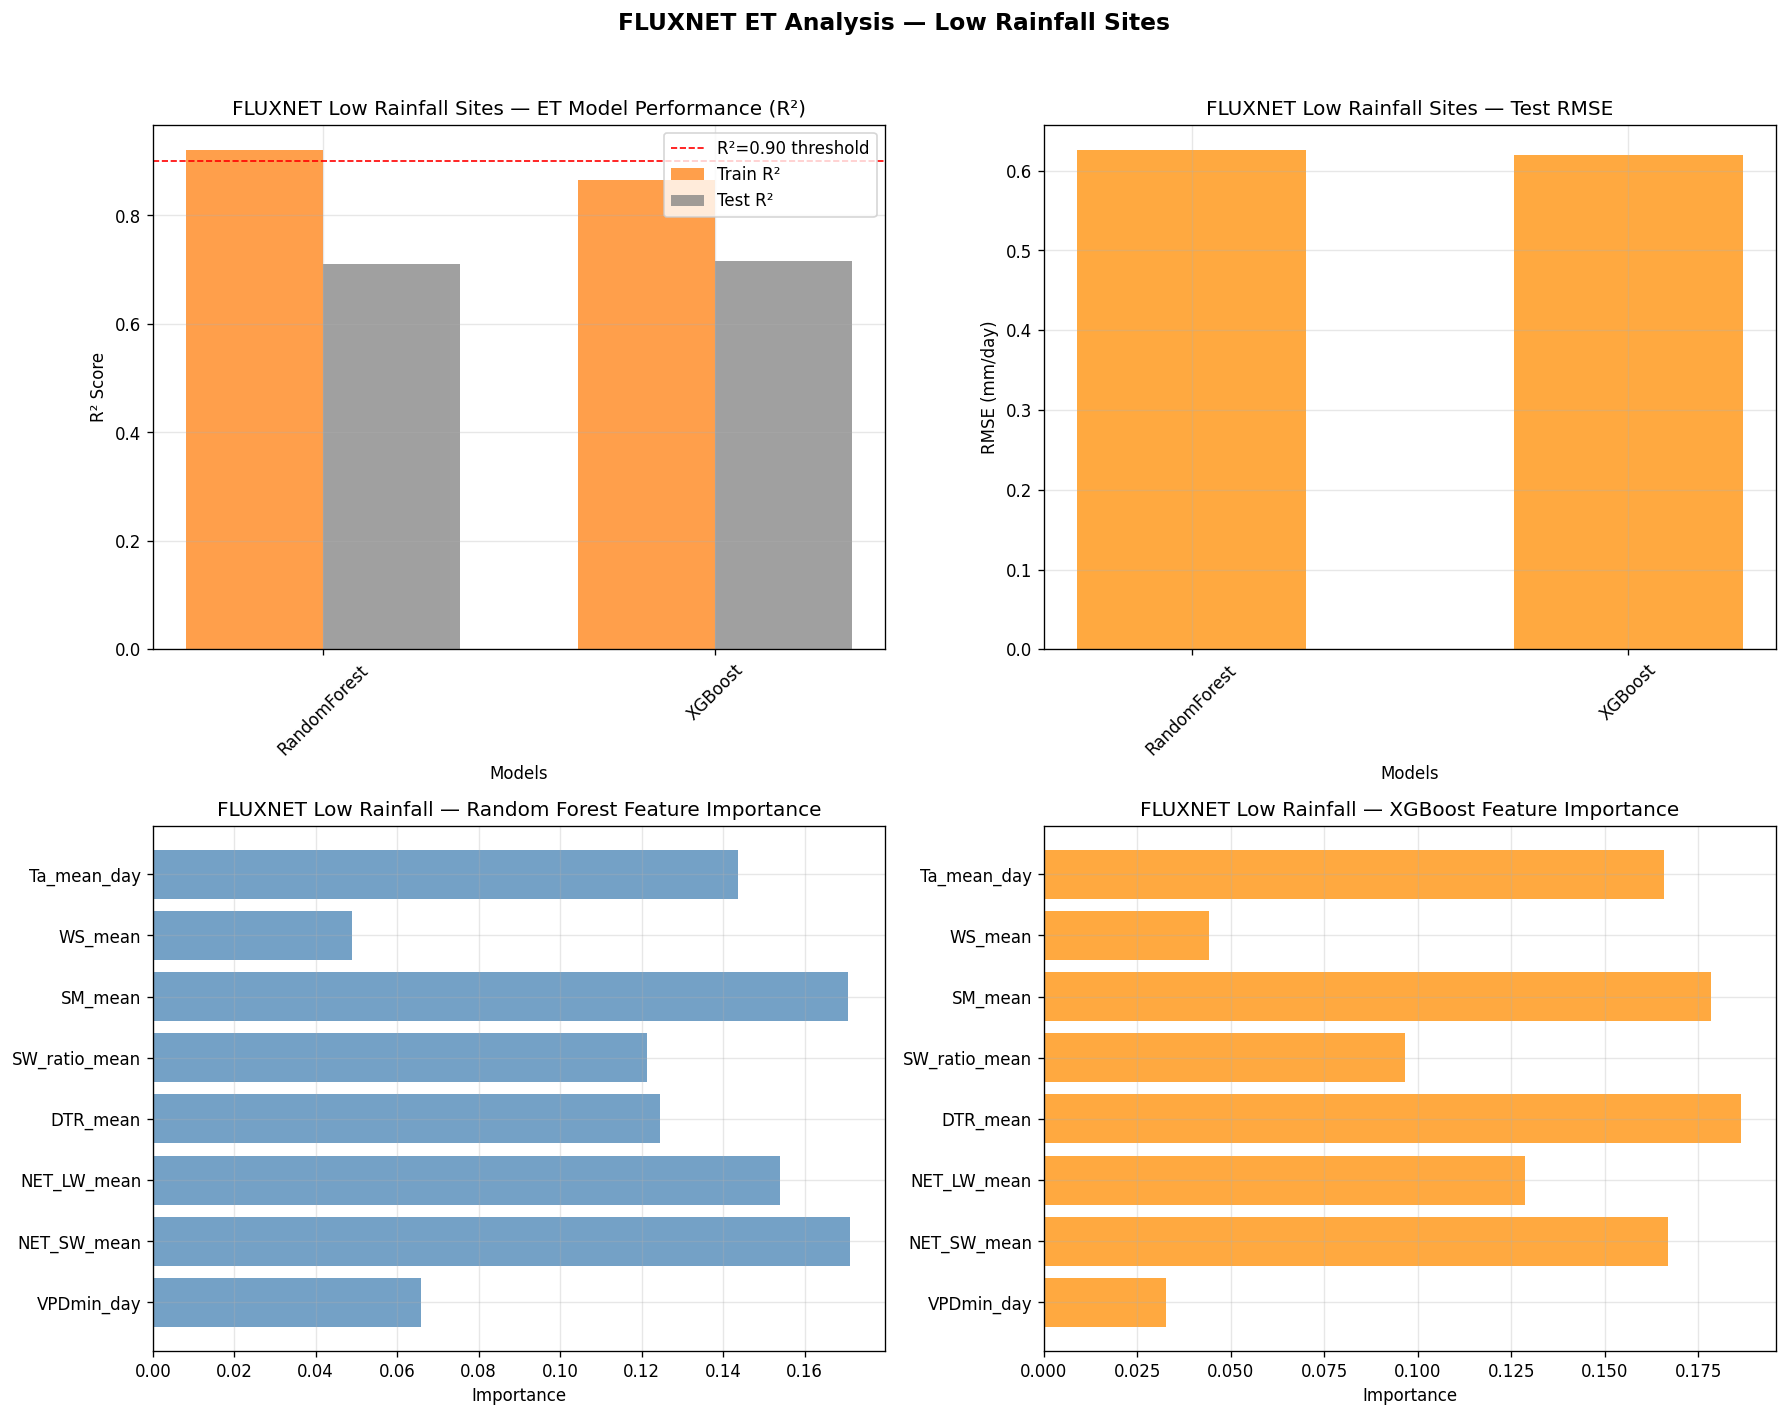

<Figure size 1800x1440 with 0 Axes>

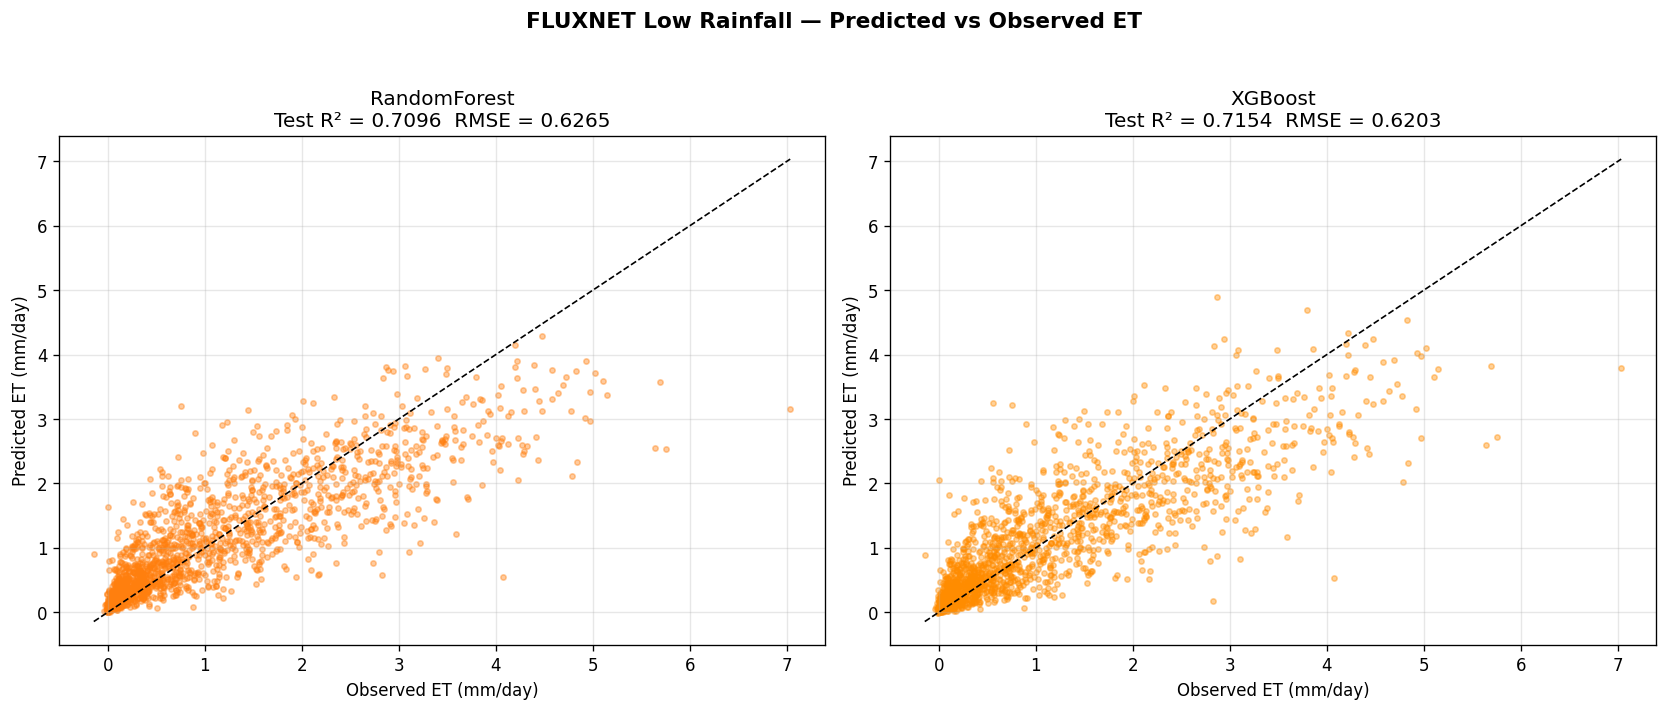

<Figure size 1800x1440 with 0 Axes>


Detailed Results: FLUXNET Low Rainfall ET
       Model Train R² Test R² Train RMSE Test RMSE Train MAE Test MAE
RandomForest   0.9214  0.7096     0.3157    0.6265    0.2096   0.4311
     XGBoost   0.8656  0.7154     0.4127    0.6203    0.2836   0.4196

SHAP Analysis for Low Rainfall ...
  Computing SHAP for RandomForest ...


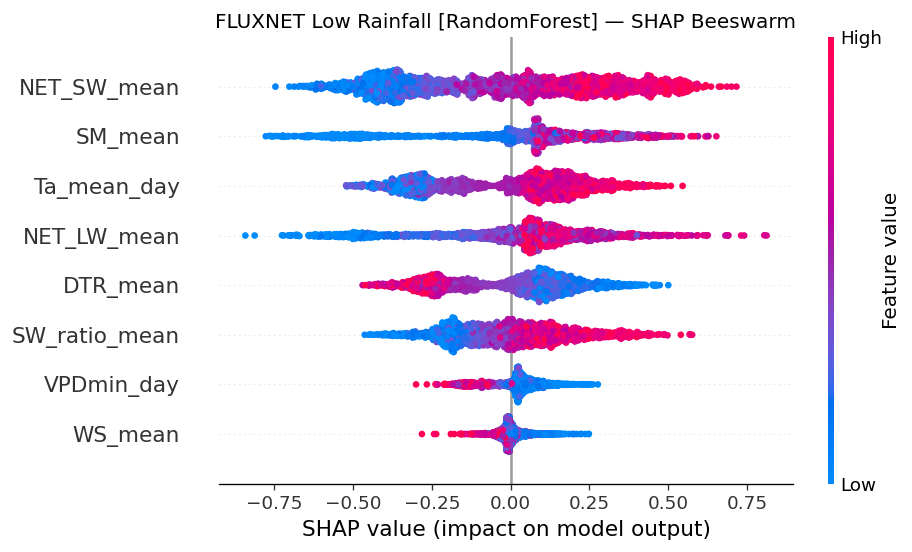

<Figure size 1800x1440 with 0 Axes>

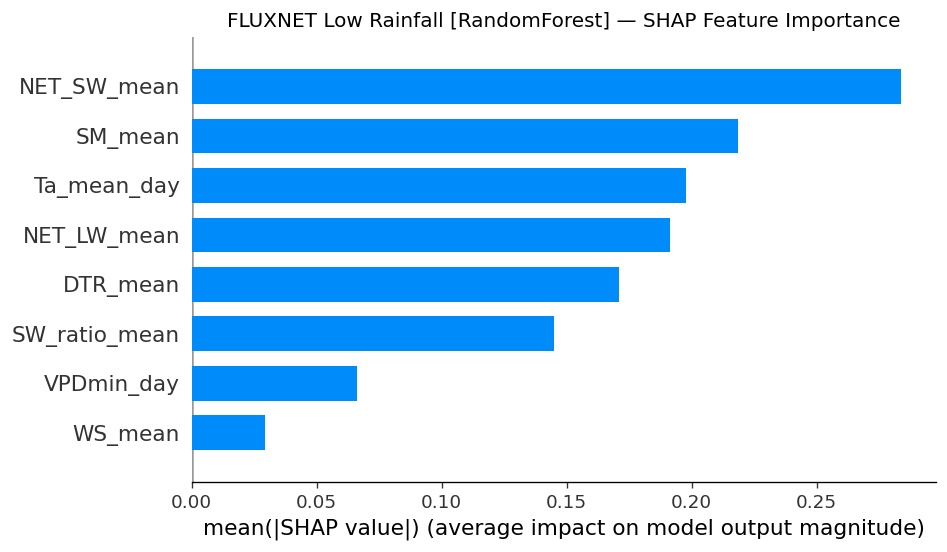

<Figure size 1800x1440 with 0 Axes>

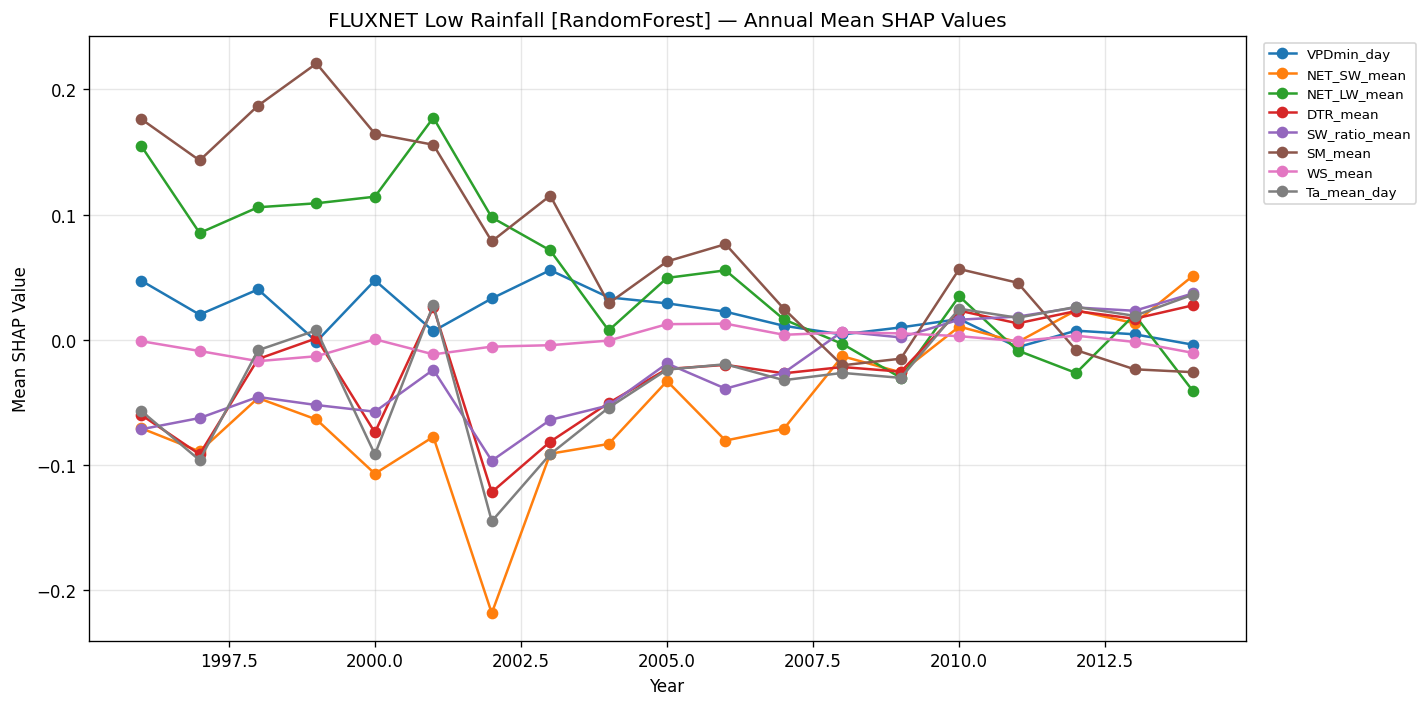

<Figure size 1800x1440 with 0 Axes>

  ✅ SHAP complete for RandomForest
  Computing SHAP for XGBoost ...


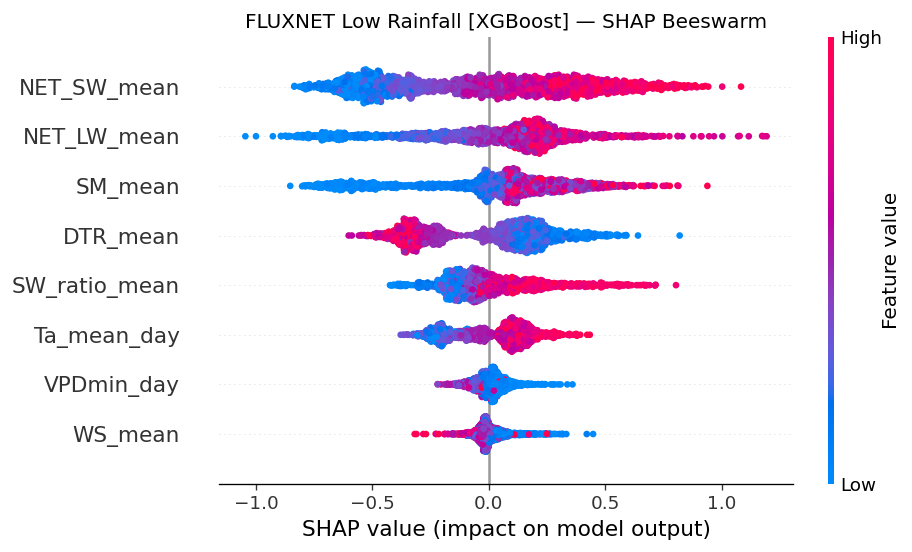

<Figure size 1800x1440 with 0 Axes>

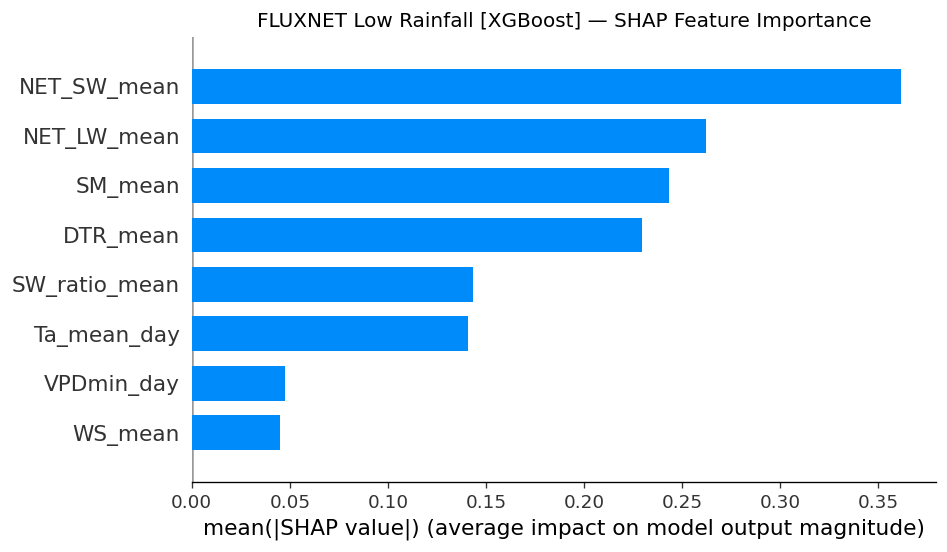

<Figure size 1800x1440 with 0 Axes>

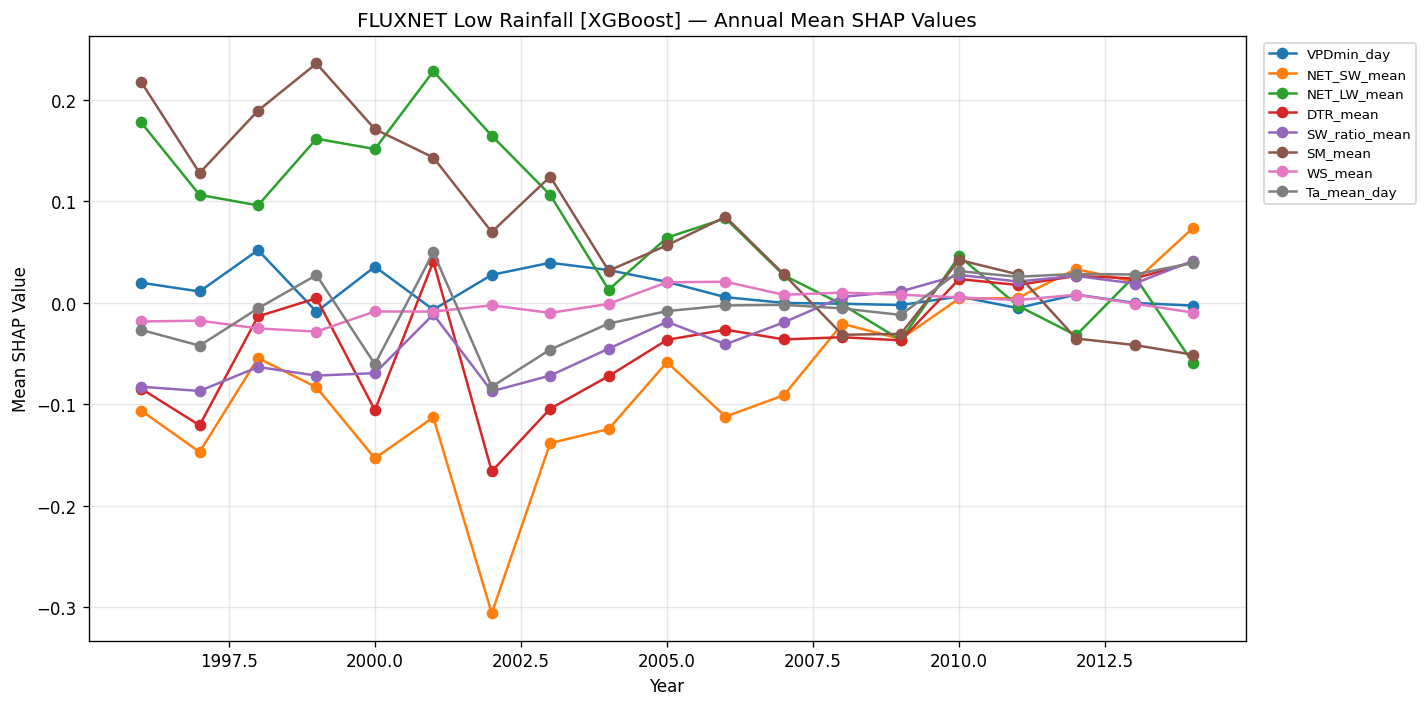

<Figure size 1800x1440 with 0 Axes>

  ✅ SHAP complete for XGBoost
  ✅ SHAP Analysis complete for Low Rainfall

Analysing radiation & ET patterns for Low Rainfall ...


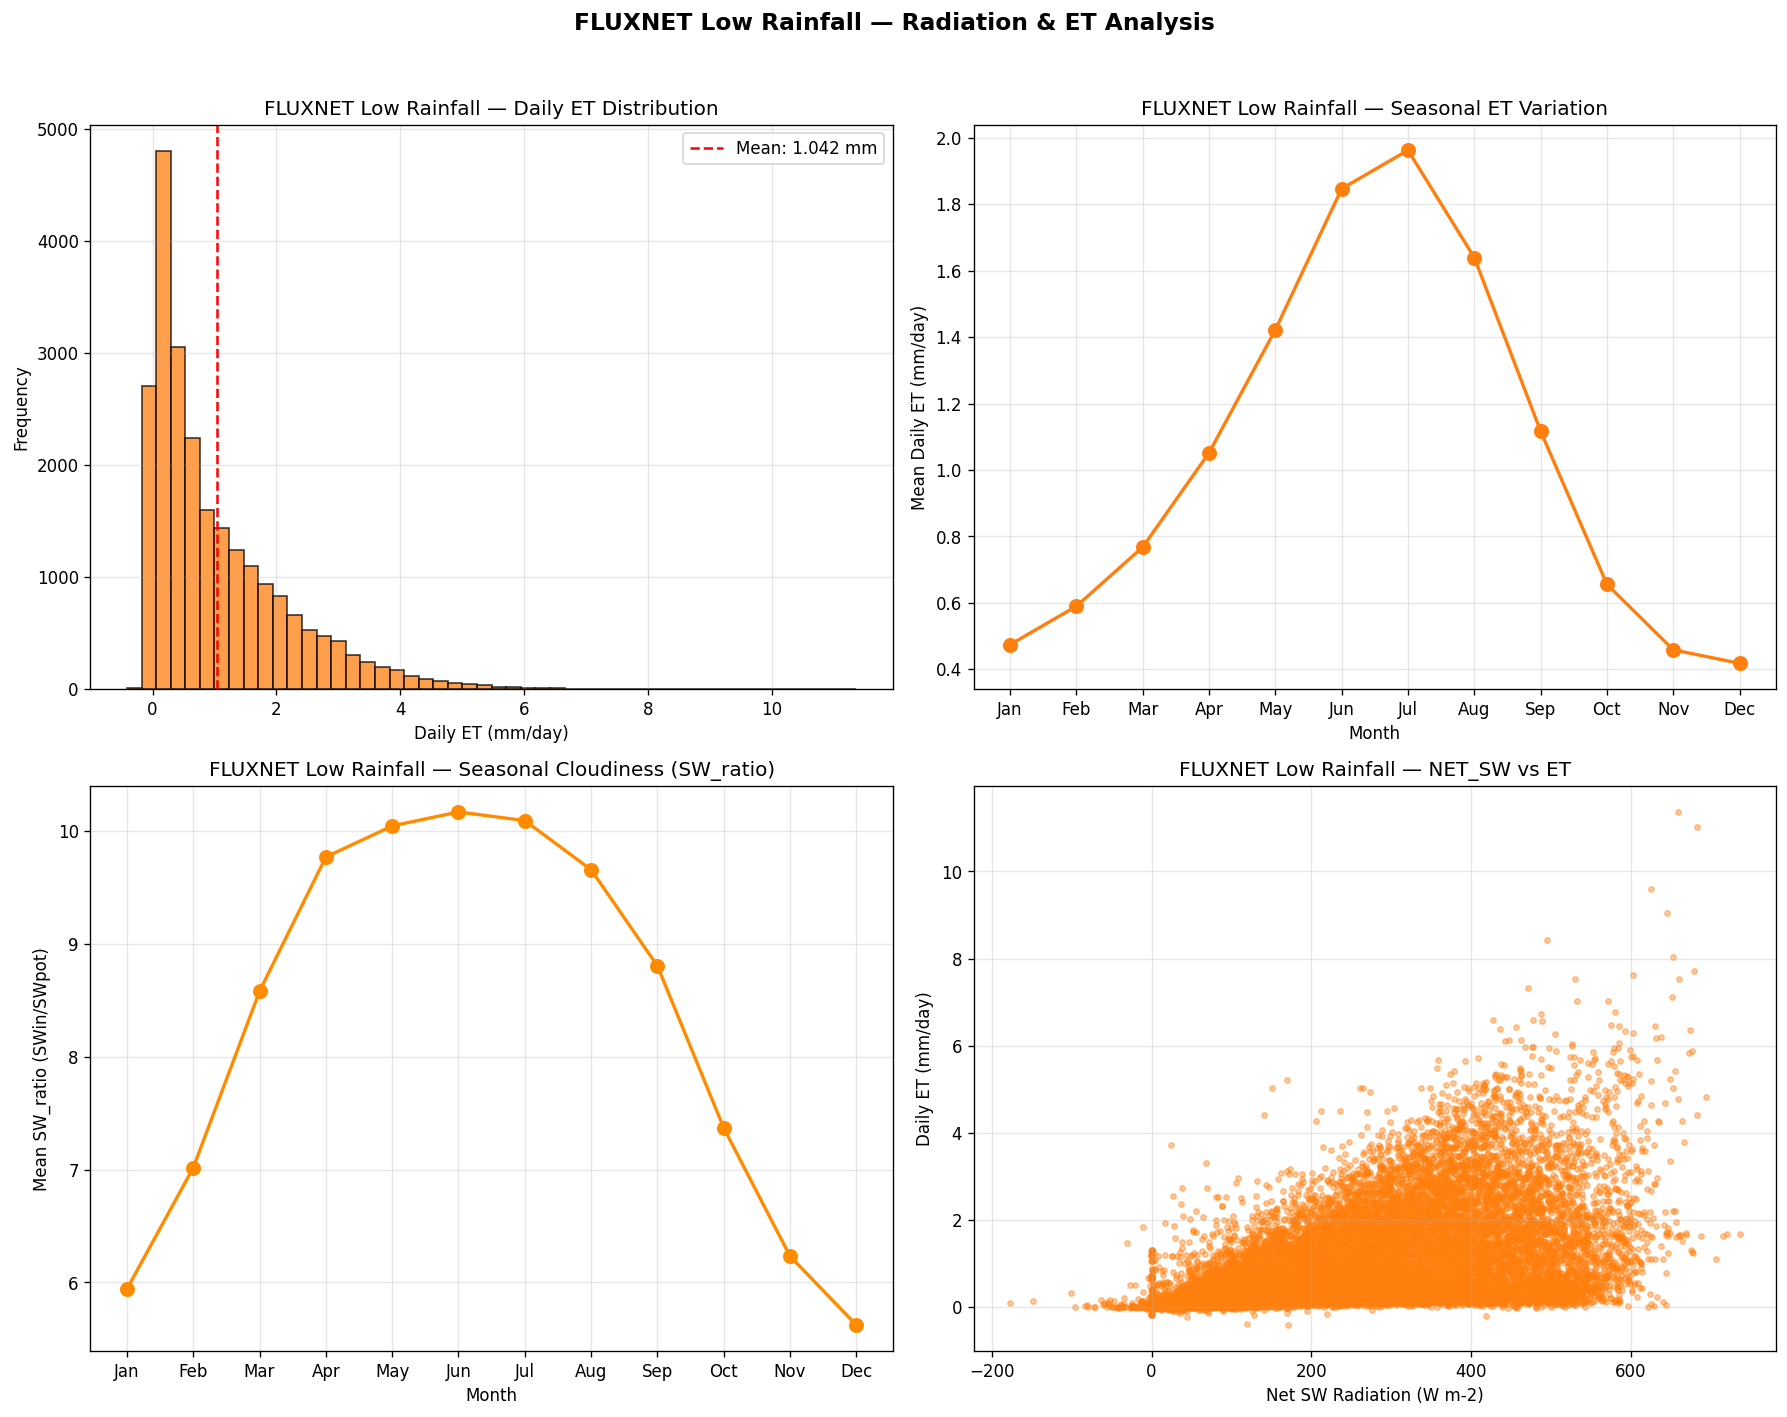

<Figure size 1800x1440 with 0 Axes>


✅ Low Rainfall Analysis Complete!

🎉 Low Rainfall FLUXNET ET Pipeline Complete!


In [ ]:
####### Module 13: Main execution #######

# ── USER: set your LOW rainfall zip path ──────────────────────────
LOW_ZIP = '/content/drive/MyDrive/LOW.zip'
# ──────────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("  FLUXNET ET Analysis — LOW RAINFALL Sites (< 500 mm)")
print("  Models: RandomForest & XGBoost")
print("="*60)

low_out = fluxnet_rainfall_pipeline(LOW_ZIP, GROUP_LABEL, LOW_RAIN_FEATURES)

if low_out and low_out['results']:
    plot_results(low_out['results'], GROUP_LABEL, LOW_RAIN_FEATURES)
    plot_scatter_both_models(low_out['results'], GROUP_LABEL)
    print_detailed_results(low_out['results'], 'FLUXNET Low Rainfall ET')
    perform_shap_analysis(low_out['results'], low_out['clean_df'],
                          LOW_RAIN_FEATURES, GROUP_LABEL)
    analyze_rainfall_radiation(low_out['combined_daily'], GROUP_LABEL)
    print("\n\u2705 Low Rainfall Analysis Complete!")
else:
    print("\n\u274c Low Rainfall analysis failed. Check zip path and CSV structure.")

del low_out; gc.collect()
print("\n\U0001f389 Low Rainfall FLUXNET ET Pipeline Complete!")



# Part 2: HIGH_FINALE


In [ ]:
# ── Mount Google Drive ────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
####### Module 1 (High): Import libraries #######
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib
plt.rcParams['figure.dpi']     = 120
plt.rcParams['figure.figsize'] = (15, 12)

import seaborn as sns
from datetime import datetime
import warnings, gc, os, zipfile, glob
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
####### Module 2 (High): Import SHAP #######
import shap
print("SHAP imported successfully!")

from IPython.display import display as ipy_display
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass

SHAP imported successfully!


In [ ]:
####### Module 3 (High): Constants — HIGH RAINFALL #######
LAMBDA      = 2.45e6
R           = 8.314
LP          = 1.0
LATITUDE    = 0.205258
RAIN_THRESH = 500.0   # mm — sites >= this threshold

FLUXNET_COL_MAP = {
    'TIMESTAMP_START' : 'DateTime',
    'TA_F'            : 'Ta',
    'SW_IN_F'         : 'SWin',
    'SW_OUT'          : 'SWout',
    'LW_IN_F'         : 'LWin',
    'LW_OUT'          : 'LWout',
    'VPD_F'           : 'VPD_F',
    'PA_F'            : 'PA',
    'WS_F'            : 'WS',
    'RH'              : 'RH',
    'NETRAD'          : 'NETRAD',
    'G_F_MDS'         : 'G',
    'USTAR'           : 'USTAR',
    'CO2_F_MDS'       : 'CO2',
    'SWC_F_MDS_1'     : 'SWC1',
    'SWC_F_MDS_2'     : 'SWC2',
    'P_F'             : 'P',
    'LE_F_MDS'        : 'LE',
    'NEE_VUT_REF'     : 'NEE',
    'GPP_NT_VUT_REF'  : 'GPP',
}

HIGH_RAIN_FEATURES = [
    'VPDmin_day', 'NET_SW_mean', 'NET_LW_mean',
    'DTR_mean',   'SW_ratio_mean', 'SM_mean',
    'WS_mean',    'Ta_mean_day'
]

TARGET_COL  = 'ET_day'
GROUP_LABEL = 'High Rainfall'
BAR_COLOR   = '#1f77b4'

print("Constants defined for HIGH RAINFALL notebook.")

Constants defined for HIGH RAINFALL notebook.


In [ ]:
####### Module 4 (High): Radiation calculation functions #######
def day_of_year(tindex):
    return tindex.dayofyear

def relative_distance(j):
    return 1 + 0.033 * np.cos(2 * np.pi * j / 365)

def solar_declination(j):
    return 0.409 * np.sin(2 * np.pi * j / 365 - 1.39)

def sunset_angle(sol_dec, lat):
    return np.arccos(-np.tan(lat) * np.tan(sol_dec))

def extraterrestrial_radiation(tindex, lat):
    j       = day_of_year(tindex)
    dr      = relative_distance(j)
    sol_dec = solar_declination(j)
    omega   = sunset_angle(sol_dec, lat)
    ra = (118.08 / np.pi) * dr * (
        omega * np.sin(sol_dec) * np.sin(lat) +
        np.cos(sol_dec) * np.cos(lat) * np.sin(omega)
    )
    return ra

print("Radiation functions defined.")

Radiation functions defined.


In [ ]:
####### Module 5 (High): Data loading function (FLUXNET) #######
def load_fluxnet_csv(file_path):
    try:
        needed_fluxnet_cols = list(FLUXNET_COL_MAP.keys())
        all_cols = pd.read_csv(file_path, nrows=0).columns.tolist()
        use_cols = [c for c in needed_fluxnet_cols if c in all_cols]

        df = pd.read_csv(
            file_path,
            usecols=use_cols,
            dtype=np.float32,
            na_values=[-9999, -9999.0]
        )

        rename_map = {k: v for k, v in FLUXNET_COL_MAP.items() if k in df.columns}
        df.rename(columns=rename_map, inplace=True)

        if 'DateTime' in df.columns:
            df['DateTime'] = pd.to_datetime(
                df['DateTime'].astype(np.int64).astype(str),
                format='%Y%m%d%H%M', errors='coerce'
            )
        else:
            print(f"  WARNING: No TIMESTAMP_START in {file_path}")
            return pd.DataFrame()

        gc.collect()
        return df

    except Exception as e:
        print(f"  Error loading {file_path}: {e}")
        return pd.DataFrame()


def load_zip_sites(zip_path, label):
    print(f"\nLoading {label} rainfall sites from: {zip_path}")
    site_dfs = {}

    extract_dir = f'tmp_{label.replace(" ", "_")}'
    os.makedirs(extract_dir, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'r') as z:
        csv_files = [f for f in z.namelist() if f.endswith('.csv')]
        print(f"  Found {len(csv_files)} CSV files")
        z.extractall(extract_dir)

    all_csv = glob.glob(os.path.join(extract_dir, '**', '*.csv'), recursive=True)
    for csv_file in all_csv:
        basename = os.path.basename(csv_file)
        parts    = basename.split('_')
        site_id  = parts[1] if len(parts) > 1 else basename.replace('.csv', '')

        df = load_fluxnet_csv(csv_file)
        if df.empty:
            continue

        if site_id in site_dfs:
            site_dfs[site_id] = pd.concat([site_dfs[site_id], df], ignore_index=True)
        else:
            site_dfs[site_id] = df

        del df
        gc.collect()

    for sid in site_dfs:
        site_dfs[sid].sort_values('DateTime', inplace=True)
        site_dfs[sid].reset_index(drop=True, inplace=True)

    print(f"  Loaded {len(site_dfs)} sites for {label} rainfall group")
    return site_dfs

print("Data loading functions defined.")

Data loading functions defined.


In [ ]:
####### Module 6 (High): Feature calculation (FLUXNET) #######
def calculate_features_fluxnet(df):
    df = df.copy()

    if 'Ta' in df.columns and 'RH' in df.columns:
        es = (0.6108 * np.exp((17.27 * df['Ta'].astype(float)) /
                               (df['Ta'].astype(float) + 237.3))).astype(np.float32)
        ea = (es * (df['RH'].astype(float) / 100)).astype(np.float32)
        df['VPD'] = (es - ea).astype(np.float32)
        df['VPD'] = df['VPD'].where(df['Ta'].notna() & df['RH'].notna(), np.nan)
    elif 'VPD_F' in df.columns:
        df['VPD'] = (df['VPD_F'].astype(float) / 10).astype(np.float32)
    else:
        df['VPD'] = np.nan

    sm_cols = [c for c in ['SWC1', 'SWC2'] if c in df.columns]
    if sm_cols:
        sm_vals = df[sm_cols].astype(float).div(100)
        df['SM'] = np.nanmean(sm_vals.values, axis=1).astype(np.float32)
    else:
        df['SM'] = np.nan

    if 'LE' in df.columns:
        df['ET_30min'] = ((df['LE'].astype(float) * 1800) / LAMBDA).astype(np.float32)
        df['ET_30min'] = df['ET_30min'].where(df['LE'].notna(), np.nan)
    else:
        df['ET_30min'] = np.nan

    if 'SWin' in df.columns and 'SWout' in df.columns:
        df['NET_SW'] = (df['SWin'].astype(float) - df['SWout'].astype(float)).astype(np.float32)
        df['NET_SW'] = df['NET_SW'].where(df['SWin'].notna() & df['SWout'].notna(), np.nan)
    elif 'NETRAD' in df.columns and 'SWin' in df.columns:
        df['NET_SW'] = df['SWin'].astype(np.float32)
    else:
        df['NET_SW'] = np.nan

    if 'LWin' in df.columns and 'LWout' in df.columns:
        df['NET_LW'] = (df['LWin'].astype(float) - df['LWout'].astype(float)).astype(np.float32)
        df['NET_LW'] = df['NET_LW'].where(df['LWin'].notna() & df['LWout'].notna(), np.nan)
    else:
        df['NET_LW'] = np.nan

    if 'Ta' in df.columns:
        Ta_K = df['Ta'].astype(float) + 273.15
        df['DTR'] = (LP / (R * Ta_K**2)).astype(np.float32)
        df['DTR'] = df['DTR'].where(df['Ta'].notna(), np.nan)
    else:
        df['DTR'] = np.nan

    df['SW_ratio'] = np.nan
    gc.collect()
    return df

print("Feature calculation function defined.")

Feature calculation function defined.


In [ ]:
####### Module 7 (High): Daily aggregation #######
def classify_rainfall_and_aggregate(df, lat=LATITUDE):
    if df.empty:
        return pd.DataFrame()

    df = df.copy()
    df['date'] = df['DateTime'].dt.date

    if 'SWin' in df.columns:
        df['is_day'] = (df['SWin'] >= 5).where(df['SWin'].notna(), False)
    else:
        df['is_day'] = False

    daily_dates  = pd.DatetimeIndex(pd.Series(df['date'].unique()))
    sw_pot_daily = extraterrestrial_radiation(daily_dates, lat)
    sw_pot_dict  = dict(zip(daily_dates.date, sw_pot_daily))
    df['SW_pot'] = df['date'].map(sw_pot_dict).astype(np.float32)

    if 'SWin' in df.columns:
        df['SW_ratio'] = (df['SWin'].astype(float) / df['SW_pot'].astype(float)).astype(np.float32)
        df['SW_ratio'] = df['SW_ratio'].where(df['SWin'].notna(), np.nan)

    daily_records = []
    for date, grp in df.groupby('date'):
        day_grp = grp[grp['is_day']]
        if day_grp.empty:
            day_grp = grp

        def _get(col):
            return day_grp[col].astype(float).values if col in day_grp.columns else np.array([np.nan])

        daily_records.append({
            'date'         : date,
            'VPDmin_day'   : np.nanmin(_get('VPD'))       if 'VPD'      in day_grp.columns else np.nan,
            'NET_SW_mean'  : np.nanmean(_get('NET_SW'))   if 'NET_SW'   in day_grp.columns else np.nan,
            'NET_LW_mean'  : np.nanmean(_get('NET_LW'))   if 'NET_LW'   in day_grp.columns else np.nan,
            'DTR_mean'     : np.nanmean(_get('DTR'))       if 'DTR'      in day_grp.columns else np.nan,
            'SW_ratio_mean': np.nanmean(_get('SW_ratio'))  if 'SW_ratio' in day_grp.columns else np.nan,
            'SM_mean'      : np.nanmean(_get('SM'))        if 'SM'       in day_grp.columns else np.nan,
            'WS_mean'      : np.nanmean(_get('WS'))        if 'WS'       in day_grp.columns else np.nan,
            'ET_day'       : np.nansum(_get('ET_30min'))   if 'ET_30min' in day_grp.columns else np.nan,
            'Ta_mean_day'  : np.nanmean(_get('Ta'))        if 'Ta'       in day_grp.columns else np.nan,
        })

    daily_df = pd.DataFrame(daily_records)
    daily_df['ET_day'] = daily_df['ET_day'].replace(0, np.nan)
    gc.collect()
    return daily_df


def combine_sites(site_dfs, label):
    print(f"\nAggregating sites for {label} rainfall group ...")
    all_daily = []
    for sid, df in site_dfs.items():
        print(f"  Processing site: {sid}  ({len(df)} half-hourly rows)")
        try:
            feat_df  = calculate_features_fluxnet(df)
            daily_df = classify_rainfall_and_aggregate(feat_df)
            daily_df['site'] = sid
            all_daily.append(daily_df)
        except Exception as e:
            print(f"  ERROR on site {sid}: {e}")
        finally:
            del feat_df
            gc.collect()

    if not all_daily:
        return pd.DataFrame()

    combined = pd.concat(all_daily, ignore_index=True)
    print(f"  Combined {label} daily records: {len(combined)}")
    return combined

print("Aggregation functions defined.")

Aggregation functions defined.


In [ ]:
####### Module 8 (High): Model training — RandomForest & XGBoost only #######
def train_and_evaluate_models(X, y, dataset_name, n_estimators=200):
    valid_mask = ~(X.isna().any(axis=1) | y.isna())
    X_clean = X[valid_mask].astype(np.float32)
    y_clean = y[valid_mask].astype(np.float32)

    if len(X_clean) < 50:
        print(f"  Insufficient data for {dataset_name} ({len(X_clean)} rows)")
        return None

    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y_clean, test_size=0.2, random_state=42
    )

    models = {
        'RandomForest': RandomForestRegressor(
            n_estimators=n_estimators, max_features='sqrt',
            min_samples_leaf=2, n_jobs=-1, random_state=42
        ),
        'XGBoost'     : XGBRegressor(
            n_estimators=n_estimators, learning_rate=0.05,
            max_depth=6, subsample=0.8, colsample_bytree=0.8,
            n_jobs=-1, random_state=42, verbosity=0
        ),
    }

    results = {}
    for name, model in models.items():
        print(f"  Training {name} on {dataset_name} ...")
        model.fit(X_train, y_train)
        y_pred_tr = model.predict(X_train)
        y_pred_te = model.predict(X_test)

        tr_r2   = r2_score(y_train, y_pred_tr)
        te_r2   = r2_score(y_test,  y_pred_te)
        tr_rmse = np.sqrt(mean_squared_error(y_train, y_pred_tr))
        te_rmse = np.sqrt(mean_squared_error(y_test,  y_pred_te))
        tr_mae  = mean_absolute_error(y_train, y_pred_tr)
        te_mae  = mean_absolute_error(y_test,  y_pred_te)

        results[name] = {
            'train_r2'  : tr_r2,   'test_r2'  : te_r2,
            'train_rmse': tr_rmse, 'test_rmse': te_rmse,
            'train_mae' : tr_mae,  'test_mae' : te_mae,
            'model'     : model,
            'scaler'    : None,
            'X_train'   : X_train, 'X_test'   : X_test,
            'y_train'   : y_train, 'y_test'   : y_test,
        }
        flag = '\u2705' if te_r2 >= 0.90 else '\u26a0\ufe0f '
        print(f"  {flag} {name} \u2014 Train R\u00b2: {tr_r2:.4f}  Test R\u00b2: {te_r2:.4f}")

    return results

print("Model training function defined (RandomForest & XGBoost only).")

Model training function defined (RandomForest & XGBoost only).


In [ ]:
####### Module 9 (High): Plots — DISPLAYED inline #######
def plot_results(results, group_label, features):
    if not results:
        print(f"No results to plot for {group_label}")
        return

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    models    = list(results.keys())
    train_r2  = [results[m]['train_r2']  for m in models]
    test_r2   = [results[m]['test_r2']   for m in models]
    test_rmse = [results[m]['test_rmse'] for m in models]
    x         = np.arange(len(models))
    width     = 0.35

    # R² comparison
    axes[0, 0].bar(x - width/2, train_r2, width, label='Train R\u00b2', alpha=0.75, color=BAR_COLOR)
    axes[0, 0].bar(x + width/2, test_r2,  width, label='Test R\u00b2',  alpha=0.75, color='grey')
    axes[0, 0].axhline(0.90, color='red', linestyle='--', linewidth=1, label='R\u00b2=0.90 threshold')
    axes[0, 0].set_title(f'FLUXNET {group_label} Sites \u2014 ET Model Performance (R\u00b2)')
    axes[0, 0].set_xlabel('Models'); axes[0, 0].set_ylabel('R\u00b2 Score')
    axes[0, 0].set_xticks(x); axes[0, 0].set_xticklabels(models, rotation=45)
    axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

    # RMSE comparison
    axes[0, 1].bar(x, test_rmse, width * 1.5, alpha=0.75, color='darkorange')
    axes[0, 1].set_title(f'FLUXNET {group_label} Sites \u2014 Test RMSE')
    axes[0, 1].set_xlabel('Models'); axes[0, 1].set_ylabel('RMSE (mm/day)')
    axes[0, 1].set_xticks(x); axes[0, 1].set_xticklabels(models, rotation=45)
    axes[0, 1].grid(True, alpha=0.3)

    # RF feature importance
    if 'RandomForest' in results:
        rf_imp = results['RandomForest']['model'].feature_importances_
        axes[1, 0].barh(features, rf_imp, color='steelblue', alpha=0.75)
        axes[1, 0].set_title(f'FLUXNET {group_label} \u2014 Random Forest Feature Importance')
        axes[1, 0].set_xlabel('Importance'); axes[1, 0].grid(True, alpha=0.3)

    # XGBoost feature importance
    if 'XGBoost' in results:
        xgb_imp = results['XGBoost']['model'].feature_importances_
        axes[1, 1].barh(features, xgb_imp, color='darkorange', alpha=0.75)
        axes[1, 1].set_title(f'FLUXNET {group_label} \u2014 XGBoost Feature Importance')
        axes[1, 1].set_xlabel('Importance'); axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle(f'FLUXNET ET Analysis \u2014 {group_label} Sites', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    ipy_display(plt.gcf())
    plt.close(); plt.close(); gc.collect()


def plot_scatter_both_models(results, group_label):
    """Predicted vs Observed scatter for both RF and XGBoost side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    colors = {'RandomForest': BAR_COLOR, 'XGBoost': 'darkorange'}

    for ax, name in zip(axes, ['RandomForest', 'XGBoost']):
        if name not in results:
            ax.set_visible(False)
            continue
        bm     = results[name]
        y_te   = bm['y_test']
        y_pred = bm['model'].predict(bm['X_test'])
        lim    = [min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())]
        ax.scatter(y_te, y_pred, alpha=0.4, s=10, color=colors[name])
        ax.plot(lim, lim, 'k--', linewidth=1)
        ax.set_xlabel('Observed ET (mm/day)')
        ax.set_ylabel('Predicted ET (mm/day)')
        ax.set_title(f'{name}\nTest R\u00b2 = {bm["test_r2"]:.4f}  RMSE = {bm["test_rmse"]:.4f}')
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'FLUXNET {group_label} \u2014 Predicted vs Observed ET',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    ipy_display(plt.gcf())
    plt.close(); gc.collect()


def print_detailed_results(results, dataset_name):
    if not results:
        print(f"No results for {dataset_name}")
        return
    print(f"\n{'='*55}")
    print(f"Detailed Results: {dataset_name}")
    print(f"{'='*55}")
    rows = []
    for m, v in results.items():
        rows.append({
            'Model'     : m,
            'Train R\u00b2'  : f"{v['train_r2']:.4f}",
            'Test R\u00b2'   : f"{v['test_r2']:.4f}",
            'Train RMSE': f"{v['train_rmse']:.4f}",
            'Test RMSE' : f"{v['test_rmse']:.4f}",
            'Train MAE' : f"{v['train_mae']:.4f}",
            'Test MAE'  : f"{v['test_mae']:.4f}",
        })
    print(pd.DataFrame(rows).to_string(index=False))

print("Plot functions defined.")

Plot functions defined.


In [ ]:
####### Module 10 (High): Main pipeline — HIGH RAINFALL #######
def fluxnet_rainfall_pipeline(zip_path, group_label, features):
    print(f"\n{'#'*60}")
    print(f"# FLUXNET Pipeline: {group_label} Sites")
    print(f"{'#'*60}")

    site_dfs = load_zip_sites(zip_path, group_label)
    if not site_dfs:
        print(f"\u274c No data loaded for {group_label}. Check zip path.")
        return None

    combined_daily = combine_sites(site_dfs, group_label)
    del site_dfs; gc.collect()

    if combined_daily.empty:
        print(f"\u274c No daily data for {group_label}")
        return None

    clean_df = combined_daily.dropna(subset=[TARGET_COL] + features).copy()
    print(f"  Clean daily records for ML: {len(clean_df)}")

    if len(clean_df) < 50:
        print(f"\u274c Too few clean records ({len(clean_df)}) for {group_label}")
        return None

    X = clean_df[features]
    y = clean_df[TARGET_COL]
    results = train_and_evaluate_models(X, y, f"FLUXNET {group_label} ET")

    return {
        'combined_daily': combined_daily,
        'clean_df'      : clean_df,
        'results'       : results,
    }

print("Main pipeline function defined.")

Main pipeline function defined.


In [ ]:
####### Module 11 (High): SHAP analysis — RF & XGBoost #######
def perform_shap_analysis(results, clean_df, features, group_label):
    print(f"\nSHAP Analysis for {group_label} ...")

    MAX_SHAP_ROWS = 2000
    X_full = clean_df[features].dropna()
    if len(X_full) > MAX_SHAP_ROWS:
        X_shap     = X_full.sample(MAX_SHAP_ROWS, random_state=42)
        sample_idx = X_shap.index
    else:
        X_shap     = X_full.copy()
        sample_idx = X_full.index
    X_shap = X_shap.astype(np.float32).reset_index(drop=True)

    if 'date' in clean_df.columns:
        shap_dates = clean_df.loc[sample_idx, 'date'].reset_index(drop=True)
    else:
        shap_dates = pd.Series([None] * len(X_shap))

    for model_name in ['RandomForest', 'XGBoost']:
        if model_name not in results:
            print(f"  {model_name} not found, skipping SHAP.")
            continue

        print(f"  Computing SHAP for {model_name} ...")
        model       = results[model_name]['model']
        explainer   = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_shap)
        shap_df     = pd.DataFrame(shap_values, columns=features)

        # Beeswarm
        plt.figure(figsize=(10, 6))
        shap.summary_plot(shap_values, X_shap, feature_names=features, show=False)
        plt.title(f"FLUXNET {group_label} [{model_name}] \u2014 SHAP Beeswarm")
        plt.tight_layout(); plt.show()
        ipy_display(plt.gcf()); plt.close(); gc.collect()

        # Bar
        plt.figure(figsize=(10, 6))
        shap.summary_plot(shap_values, X_shap, feature_names=features,
                          plot_type='bar', show=False)
        plt.title(f"FLUXNET {group_label} [{model_name}] \u2014 SHAP Feature Importance")
        plt.tight_layout(); plt.show()
        ipy_display(plt.gcf()); plt.close(); gc.collect()

        # Annual mean SHAP
        shap_df['date'] = pd.to_datetime(shap_dates.values, errors='coerce')
        shap_df['year'] = shap_df['date'].dt.year
        shap_df_valid   = shap_df.dropna(subset=['year'])

        if not shap_df_valid.empty:
            annual_mean_shap = (shap_df_valid
                                .drop(columns=['date'])
                                .groupby('year')[features]
                                .mean())
            fig, ax = plt.subplots(figsize=(12, 6))
            annual_mean_shap.plot(ax=ax, marker='o', linewidth=1.5)
            ax.set_title(f"FLUXNET {group_label} [{model_name}] \u2014 Annual Mean SHAP Values")
            ax.set_xlabel('Year'); ax.set_ylabel('Mean SHAP Value')
            ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
            ax.grid(True, alpha=0.3)
            plt.tight_layout(); plt.show()
        ipy_display(plt.gcf()); plt.close(); gc.collect()

        print(f"  \u2705 SHAP complete for {model_name}")

    print(f"  \u2705 SHAP Analysis complete for {group_label}")

print("SHAP function defined.")

SHAP function defined.


In [ ]:
####### Module 12 (High): Radiation & ET analysis #######
def analyze_rainfall_radiation(combined_daily, group_label):
    print(f"\nAnalysing radiation & ET patterns for {group_label} ...")
    if combined_daily.empty:
        print("  No data to analyse.")
        return

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    et_vals = combined_daily['ET_day'].dropna()
    mean_et = np.nanmean(et_vals)
    axes[0, 0].hist(et_vals, bins=50, alpha=0.75, color=BAR_COLOR, edgecolor='black')
    axes[0, 0].axvline(mean_et, color='red', linestyle='--', label=f'Mean: {mean_et:.3f} mm')
    axes[0, 0].set_xlabel('Daily ET (mm/day)'); axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title(f'FLUXNET {group_label} \u2014 Daily ET Distribution')
    axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

    combined_daily['month'] = pd.to_datetime(
        combined_daily['date'].astype(str), errors='coerce'
    ).dt.month
    monthly_et = combined_daily.groupby('month')['ET_day'].mean()
    axes[0, 1].plot(monthly_et.index, monthly_et.values, 'o-',
                    linewidth=2, markersize=8, color=BAR_COLOR)
    axes[0, 1].set_xlabel('Month'); axes[0, 1].set_ylabel('Mean Daily ET (mm/day)')
    axes[0, 1].set_title(f'FLUXNET {group_label} \u2014 Seasonal ET Variation')
    axes[0, 1].set_xticks(range(1, 13))
    axes[0, 1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                                 'Jul','Aug','Sep','Oct','Nov','Dec'])
    axes[0, 1].grid(True, alpha=0.3)

    if 'SW_ratio_mean' in combined_daily.columns:
        monthly_sw = combined_daily.groupby('month')['SW_ratio_mean'].mean()
        axes[1, 0].plot(monthly_sw.index, monthly_sw.values, 'o-',
                        linewidth=2, markersize=8, color='darkorange')
        axes[1, 0].set_xlabel('Month')
        axes[1, 0].set_ylabel('Mean SW_ratio (SWin/SWpot)')
        axes[1, 0].set_title(f'FLUXNET {group_label} \u2014 Seasonal Cloudiness (SW_ratio)')
        axes[1, 0].set_xticks(range(1, 13))
        axes[1, 0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                                     'Jul','Aug','Sep','Oct','Nov','Dec'])
        axes[1, 0].grid(True, alpha=0.3)

    if 'NET_SW_mean' in combined_daily.columns:
        valid = combined_daily.dropna(subset=['ET_day', 'NET_SW_mean'])
        axes[1, 1].scatter(valid['NET_SW_mean'], valid['ET_day'],
                           alpha=0.4, s=10, color=BAR_COLOR)
        axes[1, 1].set_xlabel('Net SW Radiation (W m-2)')
        axes[1, 1].set_ylabel('Daily ET (mm/day)')
        axes[1, 1].set_title(f'FLUXNET {group_label} \u2014 NET_SW vs ET')
        axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle(f'FLUXNET {group_label} \u2014 Radiation & ET Analysis',
                 fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    ipy_display(plt.gcf()); plt.close(); gc.collect()

print("Radiation/ET analysis function defined.")

Radiation/ET analysis function defined.



  FLUXNET ET Analysis — HIGH RAINFALL Sites (>= 500 mm)
  Models: RandomForest & XGBoost

############################################################
# FLUXNET Pipeline: High Rainfall Sites
############################################################

Loading High Rainfall rainfall sites from: /content/drive/MyDrive/HIGH.zip
  Found 80 CSV files
  Loaded 80 sites for High Rainfall rainfall group

Aggregating sites for High Rainfall rainfall group ...
  Processing site: CG-Tch  (70128 half-hourly rows)
  Processing site: CN-Du3  (35040 half-hourly rows)
  Processing site: IT-Lav  (210384 half-hourly rows)
  Processing site: US-Wi5  (17568 half-hourly rows)
  Processing site: DE-Spw  (87648 half-hourly rows)
  Processing site: US-Wi4  (70128 half-hourly rows)
  Processing site: IT-Noe  (192864 half-hourly rows)
  Processing site: US-KS1  (17520 half-hourly rows)
  Processing site: IT-Ren  (280512 half-hourly rows)
  Processing site: IT-Col  (333120 half-hourly rows)
  Processing site: 

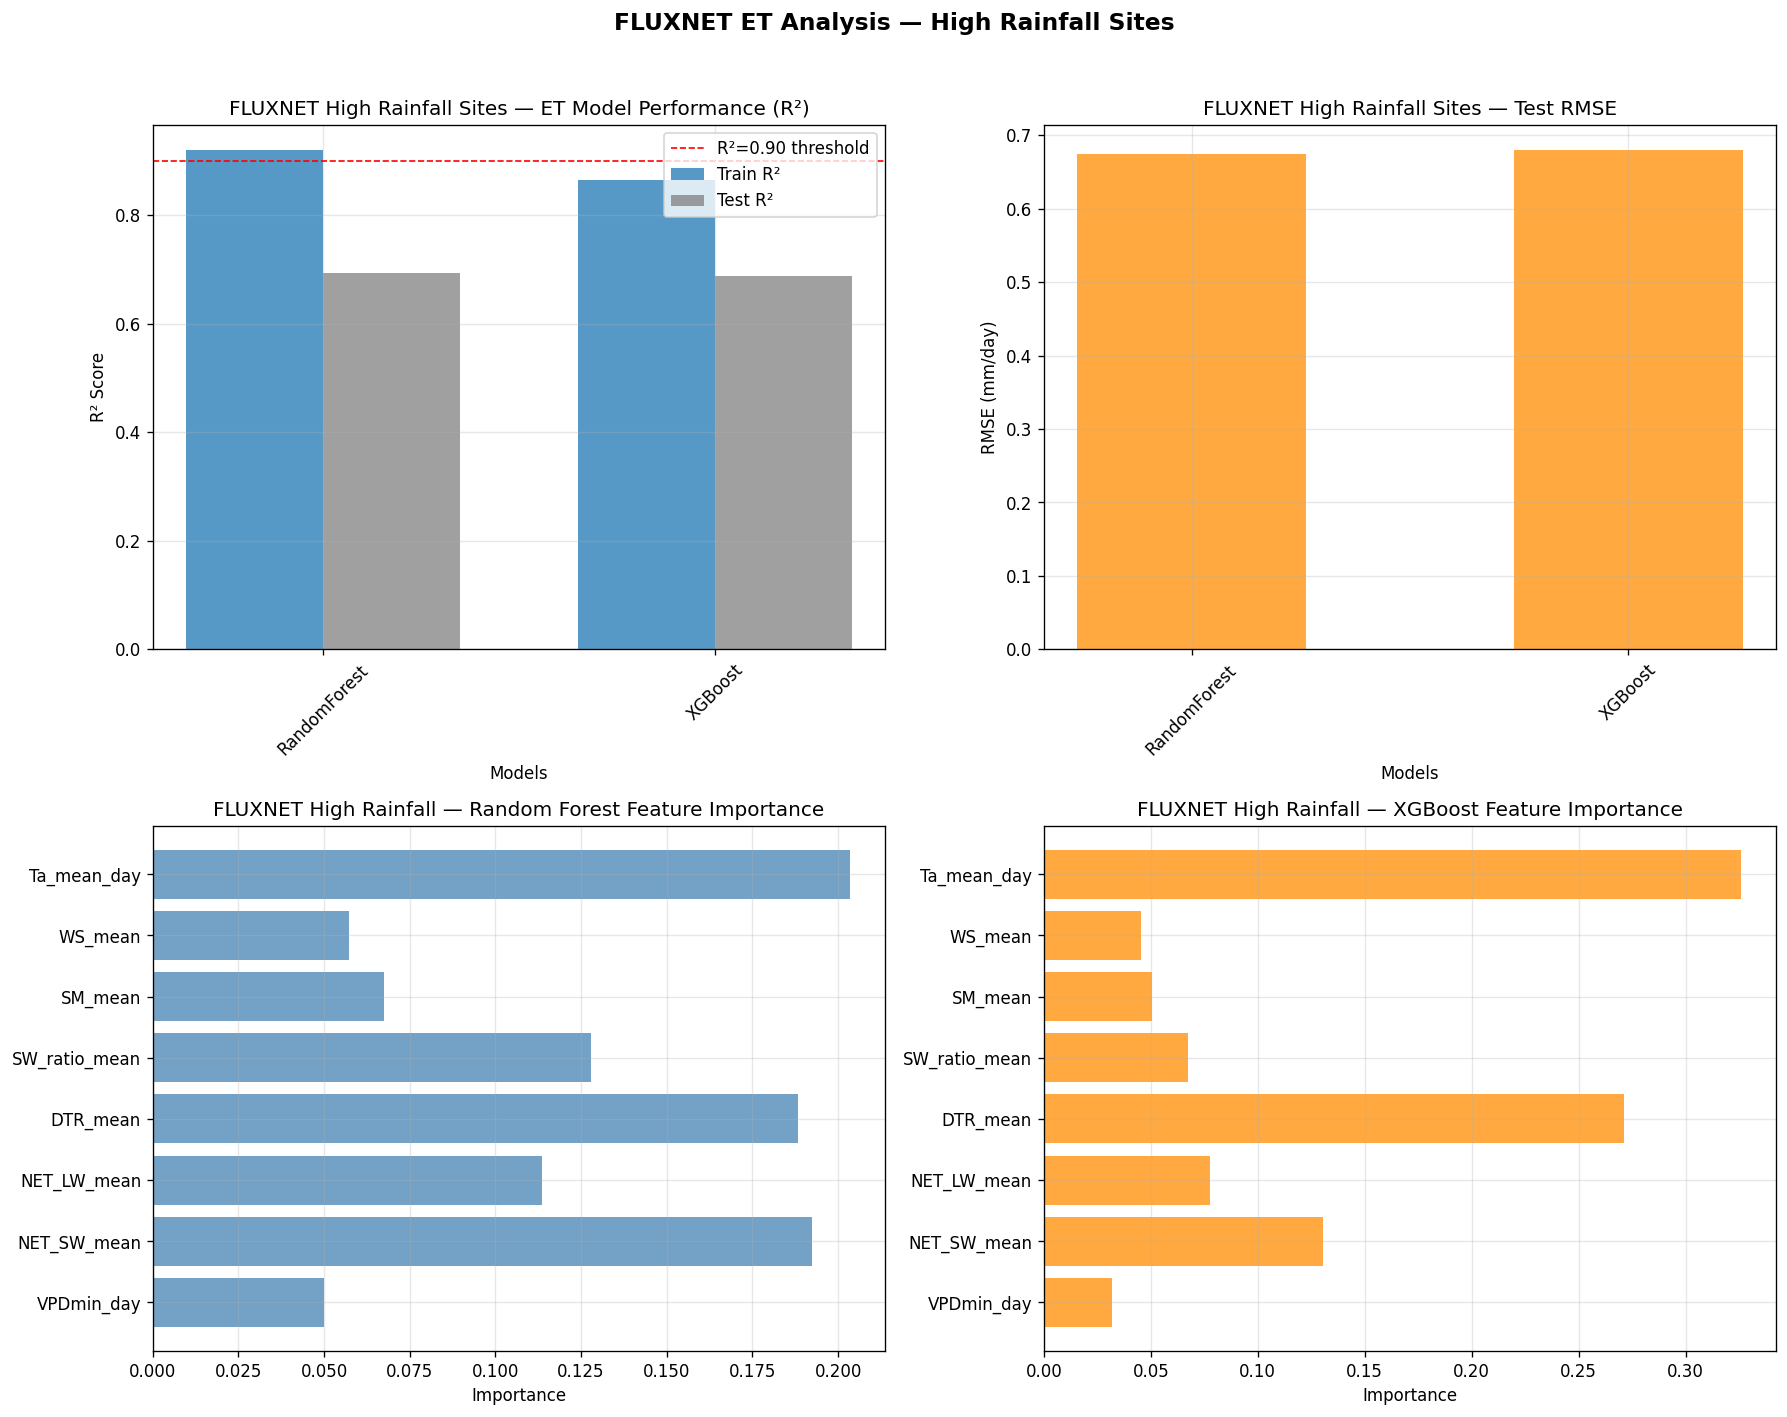

<Figure size 1800x1440 with 0 Axes>

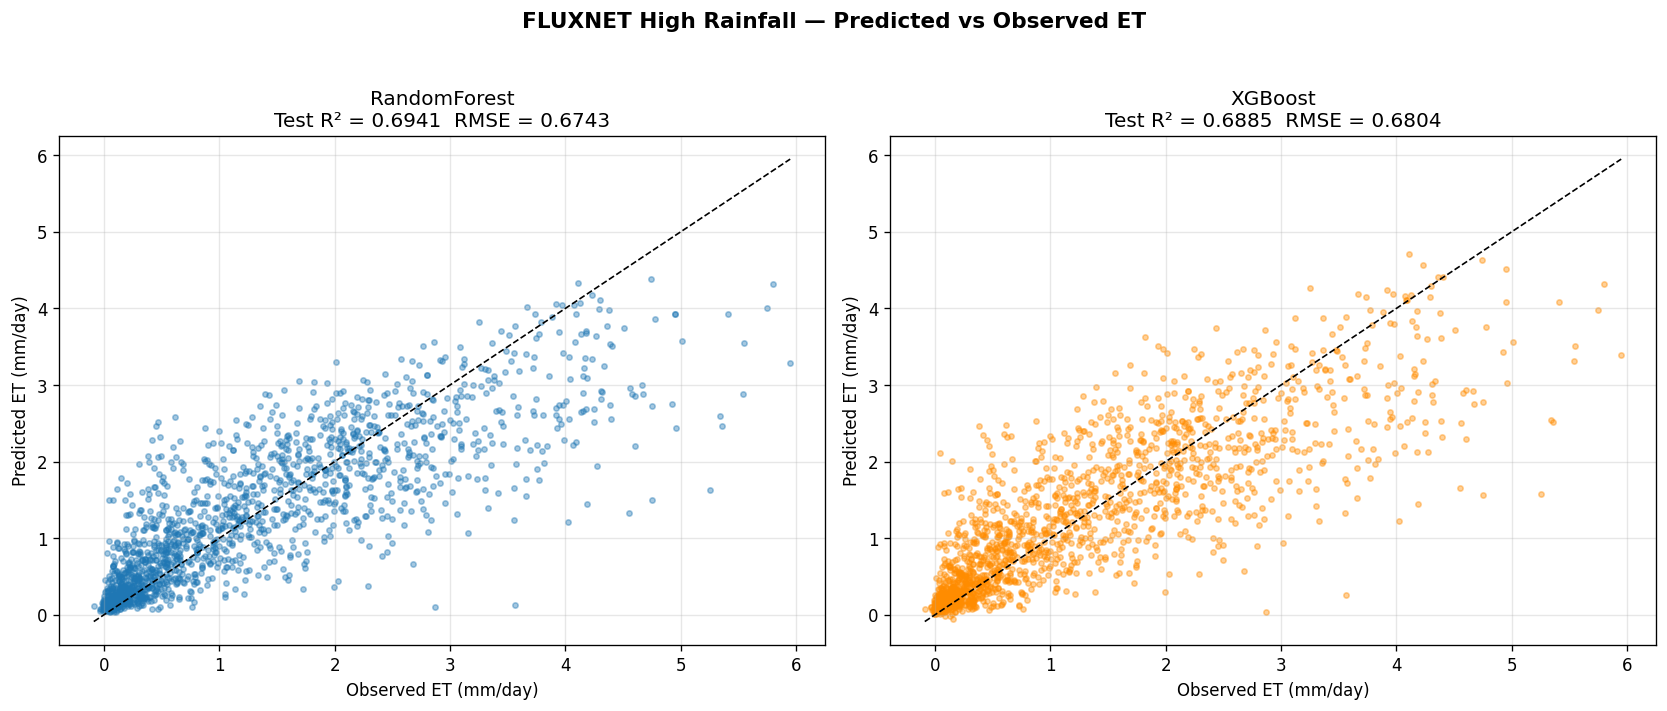

<Figure size 1800x1440 with 0 Axes>


Detailed Results: FLUXNET High Rainfall ET
       Model Train R² Test R² Train RMSE Test RMSE Train MAE Test MAE
RandomForest   0.9210  0.6941     0.3440    0.6743    0.2307   0.4653
     XGBoost   0.8646  0.6885     0.4505    0.6804    0.3174   0.4699

SHAP Analysis for High Rainfall ...
  Computing SHAP for RandomForest ...


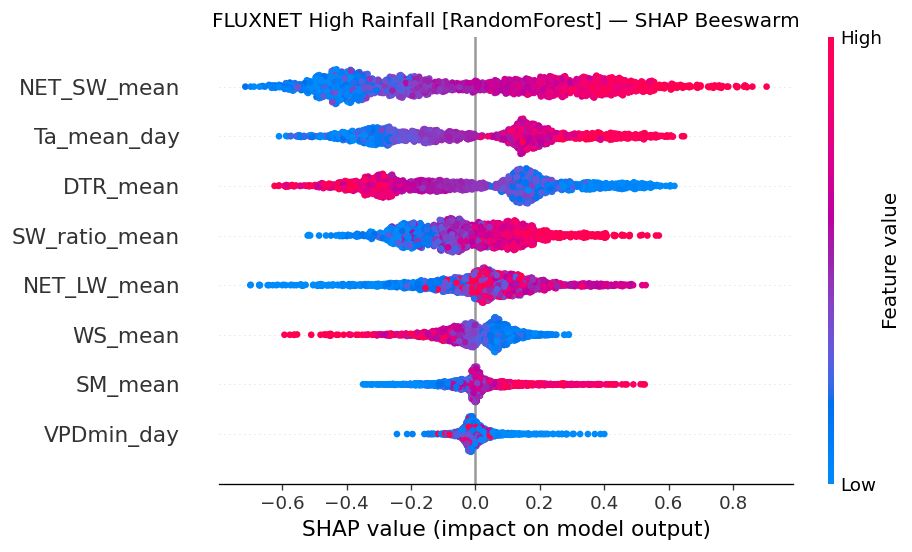

<Figure size 1800x1440 with 0 Axes>

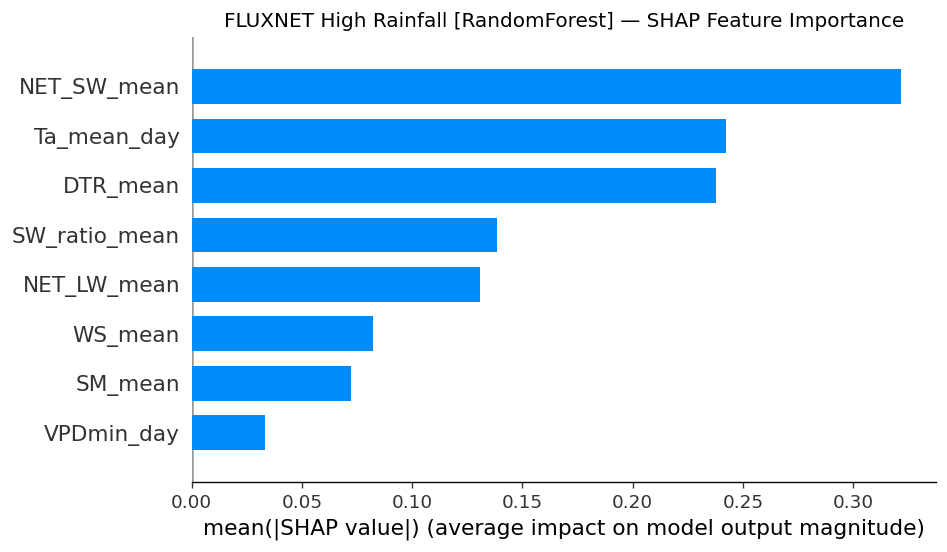

<Figure size 1800x1440 with 0 Axes>

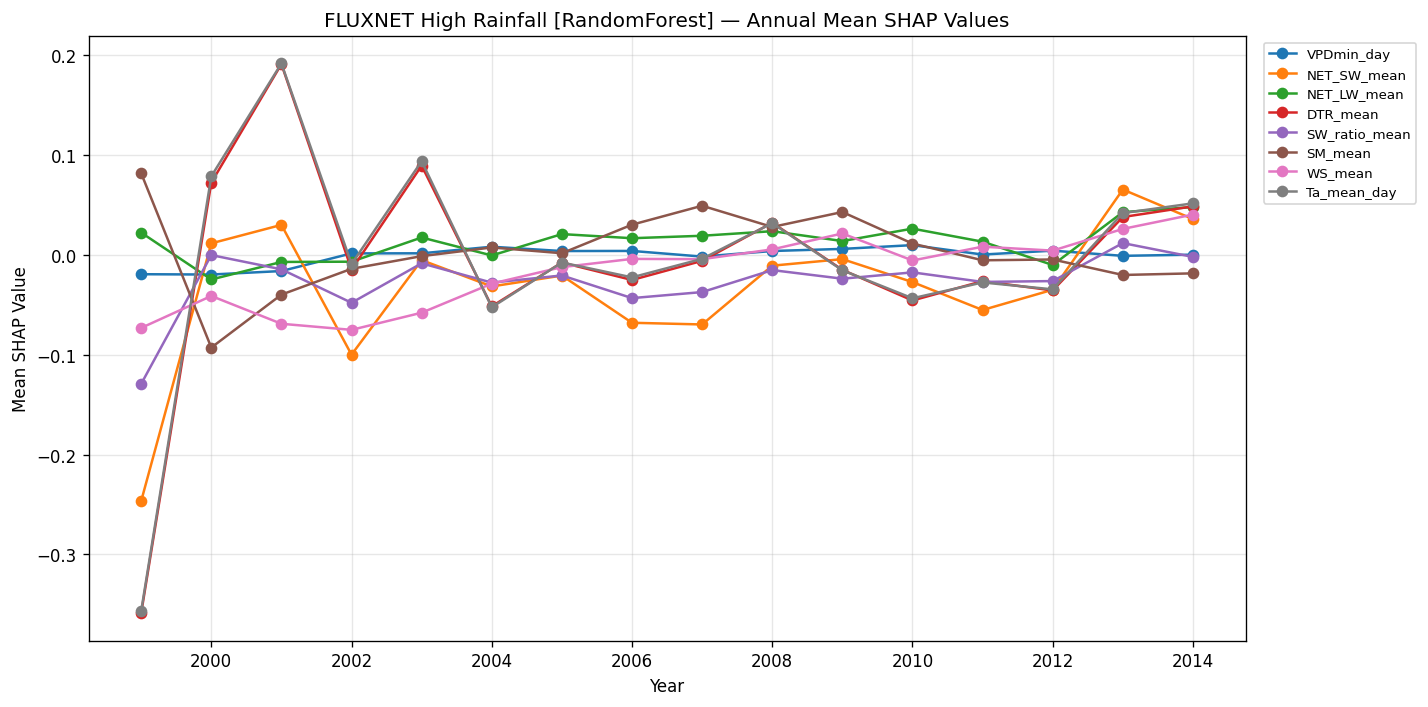

<Figure size 1800x1440 with 0 Axes>

  ✅ SHAP complete for RandomForest
  Computing SHAP for XGBoost ...


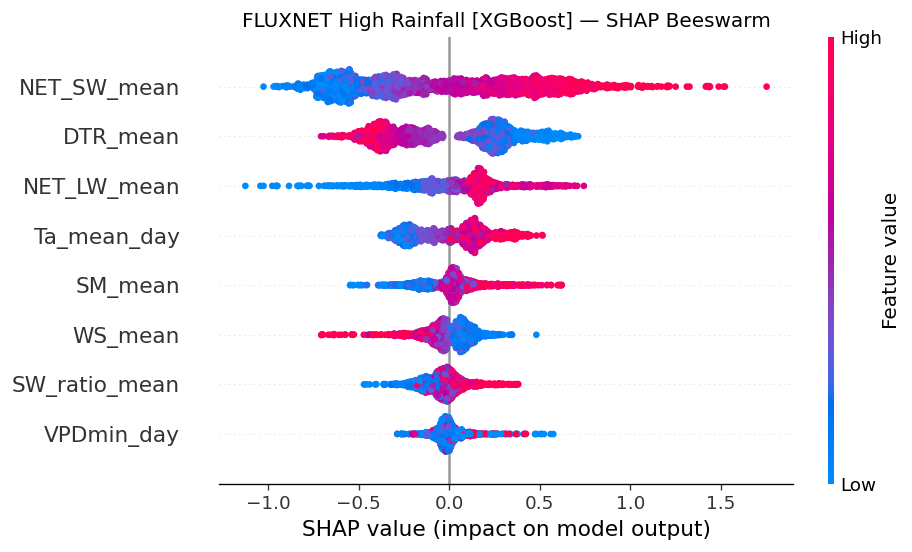

<Figure size 1800x1440 with 0 Axes>

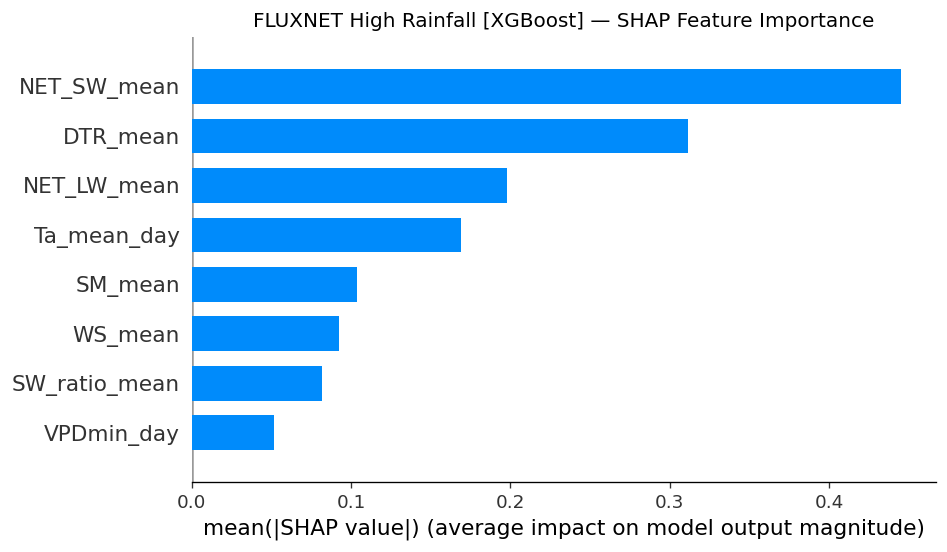

<Figure size 1800x1440 with 0 Axes>

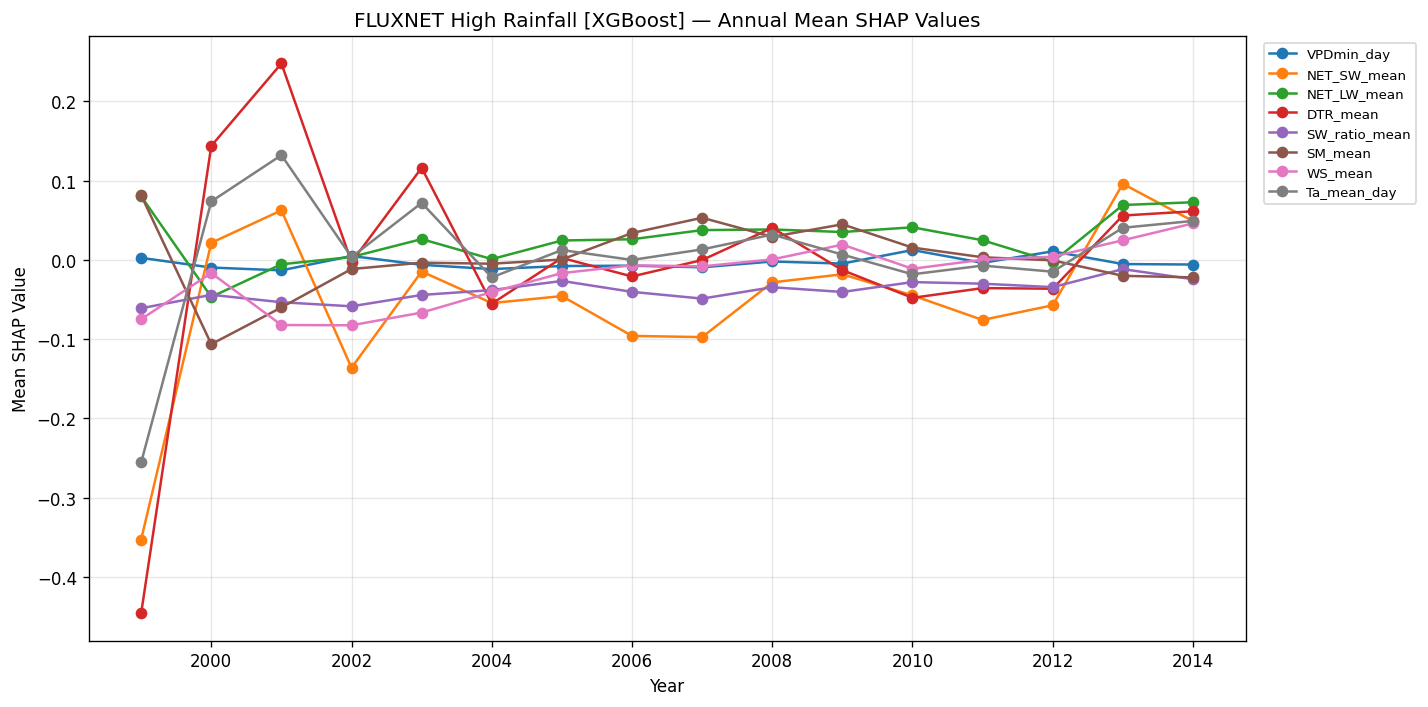

<Figure size 1800x1440 with 0 Axes>

  ✅ SHAP complete for XGBoost
  ✅ SHAP Analysis complete for High Rainfall

Analysing radiation & ET patterns for High Rainfall ...


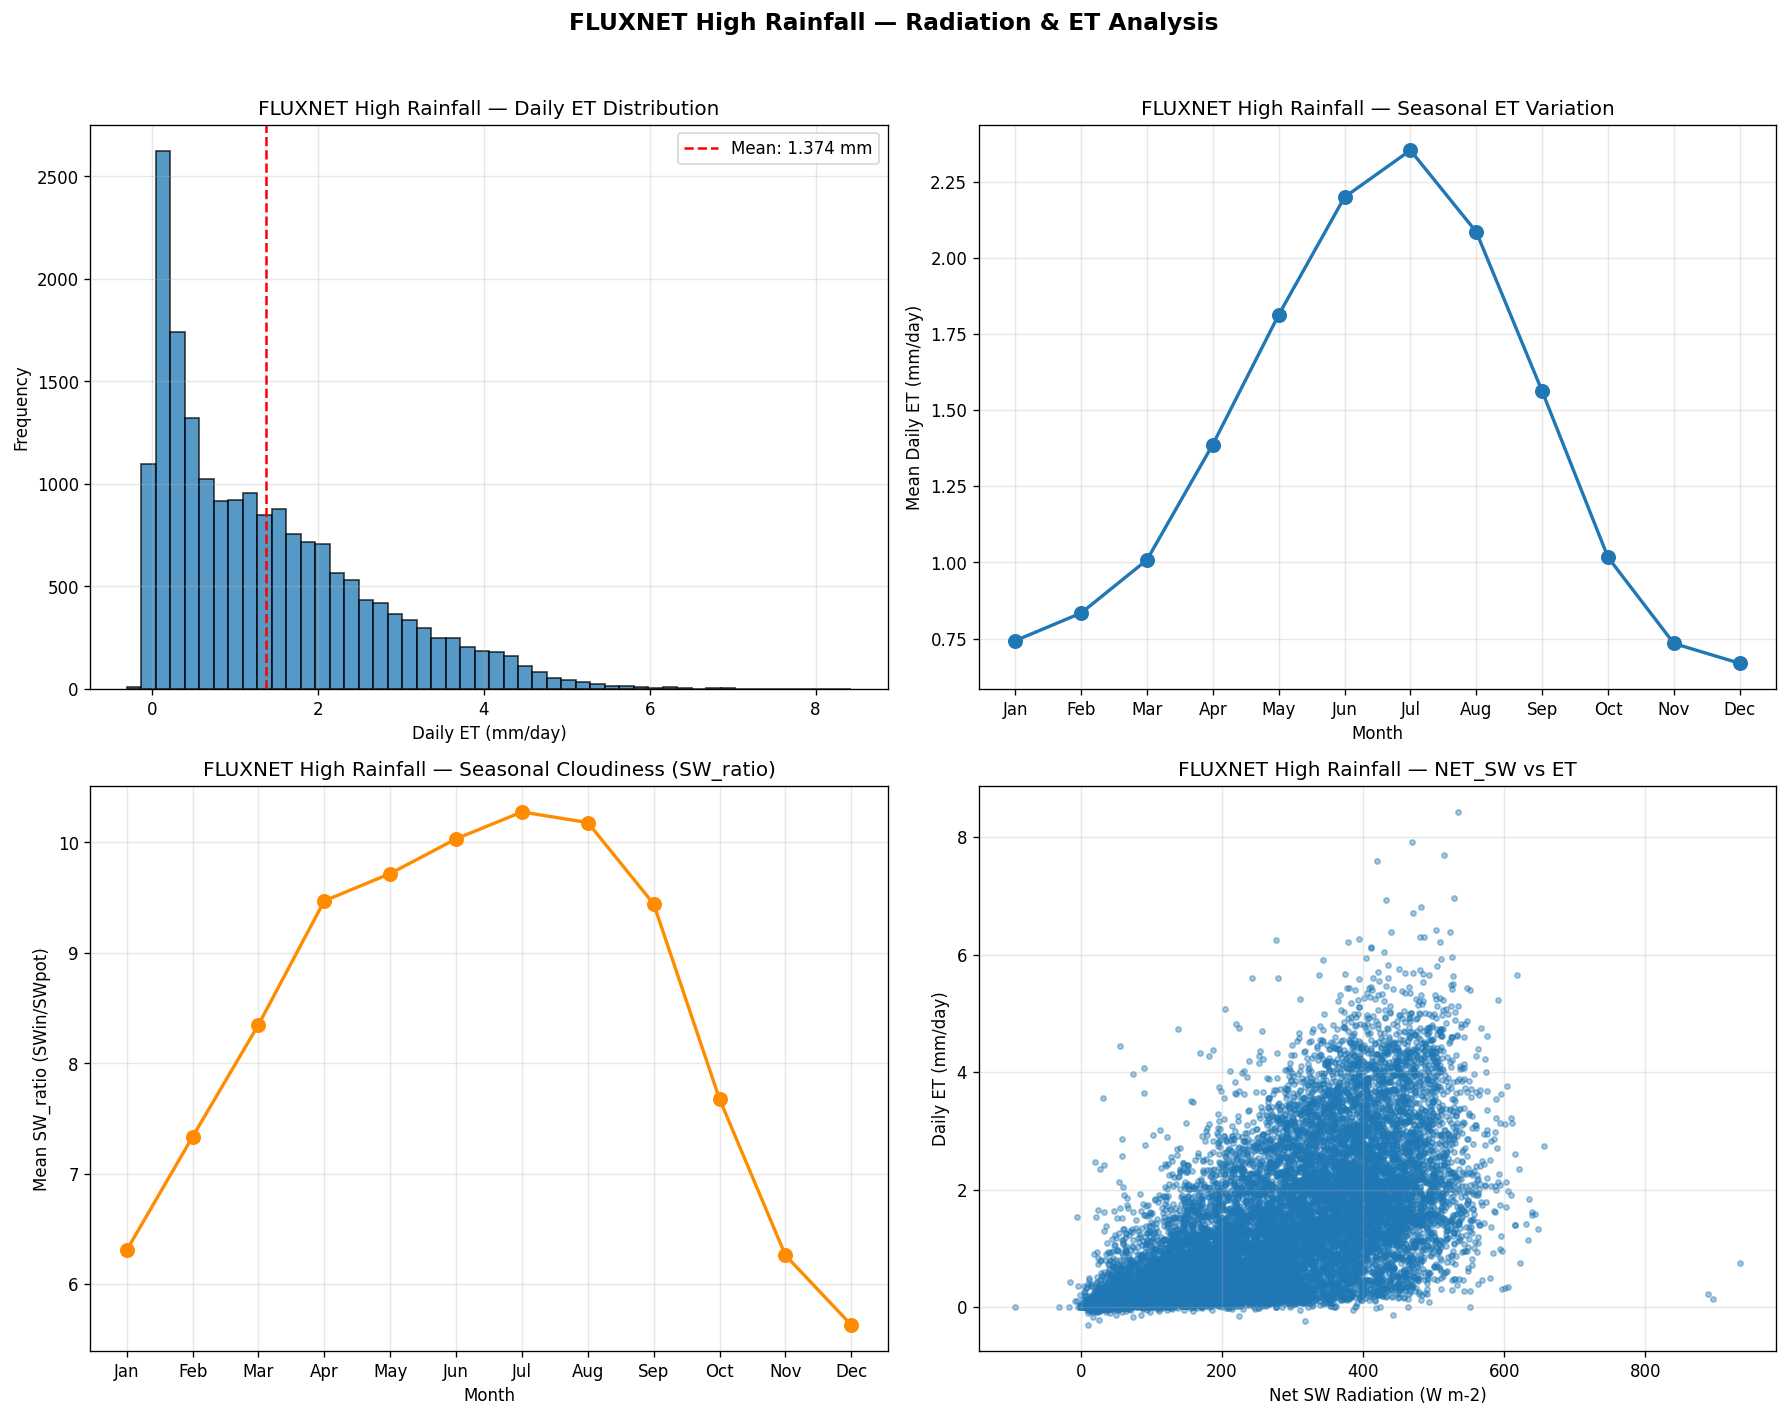

<Figure size 1800x1440 with 0 Axes>


✅ High Rainfall Analysis Complete!

🎉 High Rainfall FLUXNET ET Pipeline Complete!


In [ ]:
####### Module 13 (High): Main execution — HIGH RAINFALL ONLY #######

# ── USER: set your HIGH rainfall zip path ─────────────────────────
HIGH_ZIP = '/content/drive/MyDrive/HIGH.zip'
# ──────────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("  FLUXNET ET Analysis — HIGH RAINFALL Sites (>= 500 mm)")
print("  Models: RandomForest & XGBoost")
print("="*60)

high_out = fluxnet_rainfall_pipeline(HIGH_ZIP, GROUP_LABEL, HIGH_RAIN_FEATURES)

if high_out and high_out['results']:
    plot_results(high_out['results'], GROUP_LABEL, HIGH_RAIN_FEATURES)
    plot_scatter_both_models(high_out['results'], GROUP_LABEL)
    print_detailed_results(high_out['results'], 'FLUXNET High Rainfall ET')
    perform_shap_analysis(high_out['results'], high_out['clean_df'],
                          HIGH_RAIN_FEATURES, GROUP_LABEL)
    analyze_rainfall_radiation(high_out['combined_daily'], GROUP_LABEL)
    print("\n\u2705 High Rainfall Analysis Complete!")
else:
    print("\n\u274c High Rainfall analysis failed. Check zip path and CSV structure.")

del high_out; gc.collect()
print("\n\U0001f389 High Rainfall FLUXNET ET Pipeline Complete!")